<center><h1> WCA Analysis - Summary of the Italian speedcubing community </h1></center>

<b>Speedcubing</b> or <b>Speedsolving</b> is the activity of solving a variety of twisty puzzles as fast as possible.

The <b>World Cube Association</b> (abbreviated as WCA) is the ruling and organizing entity for speedsolving Rubik's Cube and other puzzles. It is regarded by all top speedcubers as the official organization for cubing competitions and records.

The WCA has a public database containing information about all official WCA
competitions, WCA members, and WCA competition results since 2003. You can download it for free [here](https://www.worldcubeassociation.org/results/misc/export.html).

This document presents a collection of statistics from this database, with a focus on the [Italian speedcubing community](https://www.instagram.com/cubingitaly/?hl=it).

<small><i>Updated on Sept 1st 2023.</i></small>

# Table of contents

- [Data import](#imports)
- [Competitions](#comps)
    - Most competitions
    - Most countries
    - Most competitors
    - Newcomers and Competitors
    - Female Presence at Competitions
    - Return Rate
    - Active Competitors
    - Regions competed in
    - Competition distribution
- [Events](#events)
    - Most Events Won
    - Most Events Podiumed
    - Most Popular Events
    - Most Common Events Combination
    - Average Events per competition
    - Memberships
- [SOR & kinch](#SOR)
    - Sum of Single Ranks
    - Sum of Average Ranks
    - Kinch ranks
    - Kinch against n° of cubers
- [Results](#results)
    - Medal table
    - Current best world rankings
    - Most top 10 rankings
    - Appearances in top100 Italian 3x3 singles
    - Appearances in top100 Italian 3x3 averages
    - Best podiums of all time
    - Best first average
    - Male vs Female averages distribution
- [Records](#records)
    - Italian National Records
    - Oldest Standing Records
    - Italian World and Continental records
    - Evolution of 3x3 National Records
- [Italian Championship](#IC)
    - Locations
    - List of Champions
    - Current Italian champions
    - Medal table (all events)
    - Streaks
- [Relays](#relays)
    - 2-7 relay
    - Guildford Challenge
    - Mini Guildford Challenge
    - Lucky

# Data Import <a name="imports"></a>

In [1]:
import pandas as pd
import numpy as np

import datetime
import time

from sklearn import linear_model

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12, 6)

import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

import copy

#importing mapping libraries
import geopandas as gpd
import os
from shapely.geometry import Point, Polygon

Results:

In [2]:
Results = pd.read_csv('WCA_export_Results.tsv', sep='\t', low_memory = False)

Competitions:

In [3]:
Competitions = pd.read_csv('WCA_export_Competitions.tsv', sep='\t')

The <i>Results</i> and <i>Competitions</i> datasets are the main ones we are going to be using. 

For every result at each competition I will need to access the information about said competition, so I merge the two datasets:

In [4]:
df = Results.merge(Competitions, how='left', left_on='competitionId', right_on='id', validate = "m:1")
df = df.drop('id', 1)

In [5]:
df = df.rename(columns = {'name':'competitionName'})

In the early stages of the WCA, some results were not registered correctly. It can happen that final rounds appear before first rounds for some competitions. To fix this, I import the <i>RoundTypes</i> table, containing an index - the <i>rank</i> - that will allow me to sort them correctly, and merge it with the dataset:

In [6]:
rounds = pd.read_csv('WCA_export_RoundTypes.tsv', sep='\t', low_memory = False)

In [7]:
df = df.merge(rounds[['id','rank']], how='left', left_on='roundTypeId', right_on='id')
df = df.drop('id',1)

The final dataset looks like this:

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3778438 entries, 0 to 3778437
Data columns (total 38 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   competitionId          object
 1   eventId                object
 2   roundTypeId            object
 3   pos                    int64 
 4   best                   int64 
 5   average                int64 
 6   personName             object
 7   personId               object
 8   formatId               object
 9   value1                 int64 
 10  value2                 int64 
 11  value3                 int64 
 12  value4                 int64 
 13  value5                 int64 
 14  regionalSingleRecord   object
 15  regionalAverageRecord  object
 16  personCountryId        object
 17  competitionName        object
 18  cityName               object
 19  countryId              object
 20  information            object
 21  venue                  object
 22  venueAddress           object
 23  venueDe

#### Other useful tables and lists

Persons:

In [9]:
persons = pd.read_csv('WCA_export_Persons.tsv', sep='\t')

Events:

In [10]:
events = pd.read_csv('WCA_export_Events.tsv', sep='\t')

In [11]:
event_list = list(events['id'])
current_events = ['222', '333', '333bf', '333fm', '333mbf', '333oh', '444', '444bf', '555', '555bf', '666', '777', 'clock', 'minx', 'pyram', 'skewb', 'sq1']


Single Rankings:

In [12]:
ranks_single = pd.read_csv('WCA_export_RanksSingle.tsv', sep='\t', low_memory = False)

In [13]:
ranks_single = ranks_single.merge(persons[['id','name','countryId']], how='left', left_on='personId', right_on='id')
ranks_single = ranks_single.drop('id',1)

Average Rankings:

In [14]:
ranks_average = pd.read_csv('WCA_export_RanksAverage.tsv', sep='\t', low_memory = False)

In [15]:
ranks_average = ranks_average.merge(persons[['id','name','countryId']], how='left', left_on='personId', right_on='id')
ranks_average = ranks_average.drop('id',1)

List of multi-venue competitions:

In [16]:
multivenue = ['XA', 'XE', 'XF', 'XM', 'XN', 'XO', 'XS', 'XW']

#XA	Multiple Countries (Asia)	_Asia	XA
#XE	Multiple Countries (Europe)	_Europe	XE
#XF	Multiple Countries (Africa)	_Africa	XF
#XM	Multiple Countries (Americas)	_Multiple Continents	XM
#XN	Multiple Countries (North America)	_North America	XN
#XO	Multiple Countries (Oceania)	_Oceania	XO
#XS	Multiple Countries (South America)	_South America	XS
#XW	Multiple Countries (World)	_Multiple Continents	XW

Countries:

In [17]:
countries = pd.read_csv('WCA_export_Countries.tsv', sep='\t', low_memory = False)

In [18]:
country_list = list(df['countryId'].drop_duplicates()) #only the ones with results

real_countries = [x for x in country_list if x not in multivenue]

Championships:

In [19]:
df_ic = pd.read_csv('WCA_export_Championships.tsv', sep='\t', low_memory = False)

IC = list(df_ic[df_ic['championship_type'] == 'IT']['competition_id'])

### Functions

In [20]:
def truncate(num, n):
    if np.isnan(num) == True:
        return np.nan
    
    integer = int(num * (10**n))/(10**n)
    return float(integer)

# Truncates a number to the nth digit. 
# The WCA uses n=2 for all the officially recorded times and rounds for averages

In [21]:
def timeconvert(x):
    if x < 6000:
        return '%.2f' % (x/100)
    else:
        a = x%6000
        if a < 1000:
            return str(int(x/6000))+':0'+ '%.2f' % (a/100)
        
        return str(int(x/6000))+':' + '%.2f' % (a/100)
    
#converts time in centiseconds to minutes:seconds.centiseconds

# Competitions <a name="comps"></a>

### Most Competitions

In [22]:
df1 = df.query("personCountryId == 'Italy'"
              ).groupby('personId')['competitionId'].nunique()

df1 = pd.DataFrame(df1
        ).reset_index(
        ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
        ).drop('id', 1
        ).rename(columns = {'personId':'WCAID', 'competitionId':'Number of Competitions', 'name':'Name'})

df1 = df1[['WCAID','Name','Number of Competitions']]
df1 = df1.sort_values(by = 'Number of Competitions', ascending = False).reset_index(drop = True)

df1.index += 1
df1.head(10)

,WCAID,Name,Number of Competitions
1,2009PROV01,Matteo Provasi,163
2,2007POLI01,Lorenzo Vigani Poli,146
3,2012CANT02,Simone Cantarelli,136
4,2009ROTA01,Marco Rota,131
5,2008BRAN01,Filippo Brancaleoni,89
6,2009SANT01,Simone Santarsiero,80
7,2009COLO03,Matteo Colombo,73
8,2017DUMM01,Matteo Dummar,73
9,2014RAPO01,Tommaso Raposio,70
10,2012CAPP01,Gabriele Cappelletti,70


### Most Countries

In [23]:
dfc = df.query("personCountryId == 'Italy' & countryId not in @multivenue"
        ).groupby('personId')['countryId'].nunique()

dfc = pd.DataFrame(dfc
        ).reset_index(drop = False
        ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
        ).drop('id', 1
        ).rename(columns = {'personId':'WCAID','name':'Name','countryId':'Number of Countries'})

dfc = dfc[['WCAID', 'Name', 'Number of Countries']]
dfc = dfc.sort_values(by = 'Number of Countries', ascending = False).reset_index(drop = True)

dfc.index += 1
dfc.head(10)

,WCAID,Name,Number of Countries
1,2012CANT02,Simone Cantarelli,22
2,2017DUMM01,Matteo Dummar,21
3,2019CRIP01,Jordan Crippa,19
4,2007POLI01,Lorenzo Vigani Poli,18
5,2008BRAN01,Filippo Brancaleoni,18
6,2009SANT01,Simone Santarsiero,15
7,2011TRON02,Sebastiano Tronto,14
8,2016GAMM01,Vincenzo Maria Gammino,12
9,2008ZOFF01,Tommaso Zoffoli,11
10,2009MORI05,Paolo Moriello,10


Jordan has visited N of his M countries in 2023 alone

### Most Competitors

In [24]:
big = df.query("countryId == 'Italy'").groupby("competitionId")['personId'].nunique()

big = pd.DataFrame(big
        ).rename(columns = {"personId":"Competitors"}
        ).sort_values(by = "Competitors", ascending = False
        ).reset_index(drop = False)

big.index += 1

big.head(10)

,competitionId,Competitors
1,ItalianChampionship2019,179
2,NexCubeItalianOpen2023,160
3,ItalianChampionship2022,147
4,MuggioMinxOpen2022,147
5,ItalianChampionship2018,146
6,ItalianChampionship2021,136
7,CubingItalyforCharity2023,122
8,ItalianChampionship2017,118
9,AOpeninRome2022,114
10,ParthenopeOpen2023,111


### Newcomers and competitors distribution

In [25]:
newcomer = df.query("personCountryId == 'Italy'") #italians
f = list(persons.query("gender == 'f'")['id']) #female competitors

dict_new = {}

for k in range(2003,1+int(datetime.datetime.now().year)):
    buff = newcomer[newcomer['personId'].str.contains(str(k))] #solo ID anno k
    buff2 = newcomer.query("year == @k")
    dict_new[k] = (buff['personId'].nunique(),
                   buff2.groupby('personId')['competitionId'].nunique().sum(),
                   buff2.query("countryId == 'Italy'")['competitionId'].nunique(),
                   buff.query("personId in @f")['personId'].nunique(),
                   buff2.query("personId in @f")['personId'].nunique())
    
    
new = pd.DataFrame.from_dict(dict_new, orient="index"
                    ).reset_index(drop=False
                    ).rename(columns={"index":"Year", 0:"Newcomers", 1:"Competitors", 2:"Competitions", 3:"Female Newcomers", 4:"Female Competitors"}
                    ).sort_values(by = 'Year', ascending = True
                    ).reset_index(drop = True)

new.index += 1

#ratios
new = new.astype(int)
new['newcomer_ratio'] = new['Newcomers'] / new['Competitors']
new['f_newcomer_ratio'] = new['Female Newcomers'] / new['Female Competitors']
new['f_ratio'] = new['Female Competitors'] / new['Competitors']

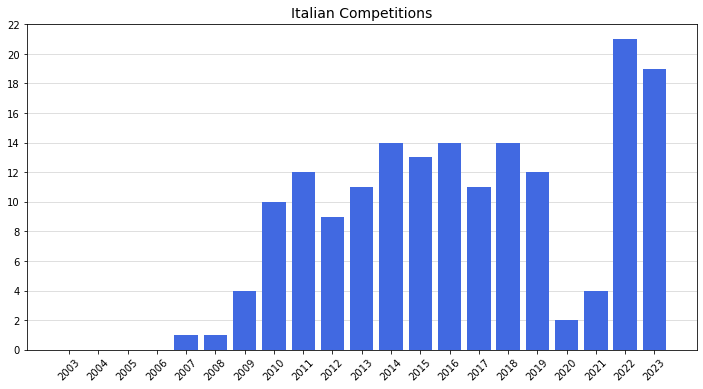

In [26]:
plt.figure
plt.grid(visible = True, which='major', axis='y', alpha = 0.5, zorder = 1)
plt.bar(new['Year'], new['Competitions'], zorder = 2, color = '#4169e1');
plt.title('Italian Competitions', fontsize = 14);
plt.xticks(new['Year']);
plt.yticks(list(range(0,23,2)))
plt.xticks(rotation=45);

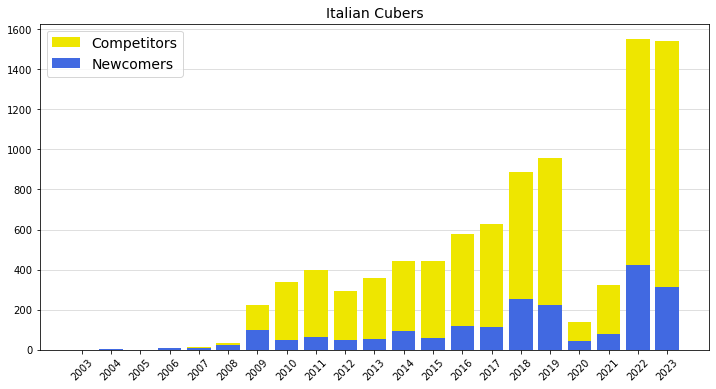

In [27]:
plt.figure
plt.grid(visible = True, which='major', axis='y', alpha = 0.5, zorder = 1)
plt.bar(new['Year'], new['Competitors'], color = '#eee600', zorder = 2);
plt.bar(new['Year'], new['Newcomers'], zorder = 3, color = '#4169e1');
plt.title('Italian Cubers', fontsize = 14);
plt.legend(['Competitors','Newcomers'], fontsize = 14)
plt.xticks(new['Year']);
plt.xticks(rotation=45);


In 2022 we had 662 unique competitors and almost 1600 total registrations.<br>
In 2023 we had reached those numbers by October (?)

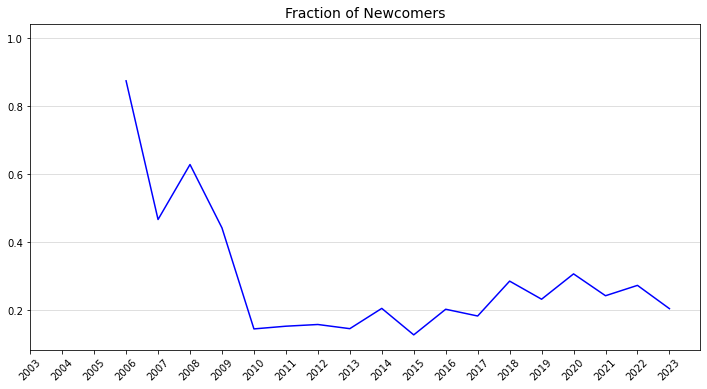

In [28]:
plt.figure
plt.grid(visible = True, which='major', axis='y', alpha = 0.5, zorder = 1)
plt.plot(new['Year'], new['newcomer_ratio'], color = 'b', zorder = 2);
plt.title('Fraction of Newcomers', fontsize = 14);
plt.xticks(new['Year']);
plt.xticks(rotation=45);

Total number of italian competitors:

In [29]:
1 + new['Newcomers'].sum() 

#1 is Giuseppe Romeo from the 1982 World Championship that I excluded for the sake of better plots.

2057

### Female Presence at competitions

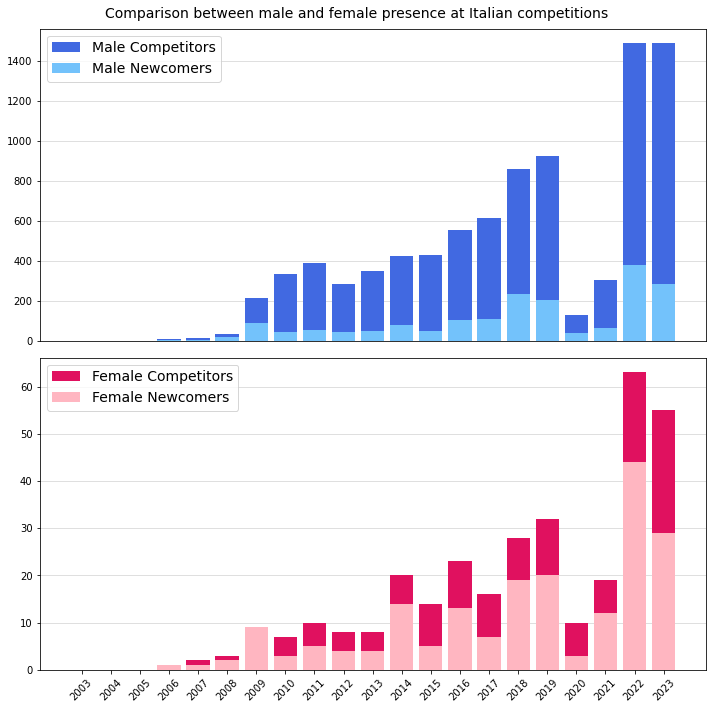

In [30]:
fig, (ax1,ax2) = plt.subplots(2, sharex=True, figsize=(10, 10))
fig.suptitle('Comparison between male and female presence at Italian competitions', fontsize = 14)

ax1.grid(visible = True, which='major', axis='y', alpha = 0.5, zorder = 1)
ax1.bar(new['Year'], new['Competitors'] - new['Female Competitors'], color = '#4169e1', zorder = 2);
ax1.bar(new['Year'], new['Newcomers'] - new['Female Newcomers'], zorder = 3, color = '#73c2fb');
ax1.legend(['Male Competitors','Male Newcomers'], fontsize = 14)
ax1.tick_params(axis = 'x', bottom=False)
               
ax2.figure
ax2.grid(visible = True, which='major', axis='y', alpha = 0.5, zorder = 1)
ax2.bar(new['Year'], new['Female Competitors'], color = '#e0115f', zorder = 2);
ax2.bar(new['Year'], new['Female Newcomers'], zorder = 3, color = '#ffb6c1');
ax2.legend(['Female Competitors','Female Newcomers'], fontsize = 14)
ax2.set_xticks(new['Year'])
ax2.tick_params(axis = 'x', labelrotation=45)

fig.tight_layout()
fig.subplots_adjust(top=0.95)

The number of female competitors has been increasing steadily throughout the years, but the numbers are still very small. It's interesting to observe that there is a much bigger ratio of newcomers compared to male competitors in almost every year. We can deduce that female competitors tend not to come back for a second WCA competition more than their male "collegues".

### Return Rate

Countries with at least 2 competitions:

In [31]:
d = df.groupby('countryId')['competitionId'].nunique()
countries2 = pd.DataFrame(d).reset_index(drop = False)
countries2 = list(countries2.query("competitionId >= 2")['countryId'])

In [32]:
dict_retrate = {}

for p in countries2:
    solve = df.query("personCountryId == @p") #only people from country p
    comps = list(solve.groupby('personId')['competitionId'].nunique()) #number of competitions for each ID
    
    competitors = len(comps) 
    returners = len([x for x in comps if x >= 2])
    
    if competitors > 25: #soglia arbitraria
        dict_retrate[p] = (competitors, returners, truncate(100*returners / competitors , 2))
    else:
        dict_retrate[p] = (-1,-1,-1)

retrate = pd.DataFrame.from_dict(dict_retrate, orient="index").reset_index(drop=False)
retrate = retrate.rename(columns={"index":"Country", 0:"Competitors", 1:"Returners", 2:"Return Rate"})
retrate = retrate[retrate['Return Rate'] >= 0]

In [33]:
retrate = retrate.sort_values(by = 'Return Rate', ascending = False).reset_index(drop = True)
retrate.index += 1
retrate.head(10)

,Country,Competitors,Returners,Return Rate
1,Estonia,246,148,60.16
2,Netherlands,1619,937,57.87
3,Czech Republic,562,324,57.65
4,Finland,702,398,56.69
5,Slovakia,260,145,55.76
6,Belgium,710,391,55.07
7,Switzerland,770,423,54.93
8,Poland,4858,2656,54.67
9,Lithuania,237,129,54.43
10,Slovenia,251,136,54.18


In [34]:
retrate.query("Country == 'Italy'")

,Country,Competitors,Returners,Return Rate
14,Italy,2057,1093,53.13


In 2021, 53% of italian competitors competed at least twice (8th in the world) <br>
In 2022, this number dropped to 52.15% (15th in the world)<br>
In 2023 the Return rate has gone back up. N% is almost top10 in the world.

### Active competitors

In [35]:
pct1 = df.query("personCountryId == 'Italy' & year >= 2021")['personId'].nunique() / persons.query("countryId == 'Italy' & subid == 1")['id'].nunique()
# percentage of competitors that have compted after 2022                                                                                             
                                                                                    
old = [str(x) for x in list(range(1982,2021))]
pct2 = df.query("personCountryId == 'Italy' & personId.str.slice(0,4) in @old & year >= 2021", engine = "python")['personId'].nunique() / df.query("personCountryId == 'Italy' & year >= 2021")['personId'].nunique()

print(str(round(pct1*100,2))+"% of all time italian competitors have competed after the Covid break.")
print(str(round(pct2*100,2))+"% of this "+str(round(pct1*100,2))+"% has a WCAID from 2019 or prior.")

48.13% of all time italian competitors have competed after the Covid break.
17.58% of this 48.13% has a WCAID from 2019 or prior.


### Regions competed in

In [36]:
#import data from regioni.csv
regions = pd.read_csv('df_regioni.csv'
            ).drop("Unnamed: 0",1
            ).rename(columns = {"codice":"competitionId"})

#aggiornato a EretumIV 2023 compreso

In [37]:
#add regions to the database
dfG = df.merge(regions, how='left', on = 'competitionId')

In [38]:
diff_regions = dfG.groupby('personId')['regionId'].nunique()

In [39]:
diff_regions = pd.DataFrame(diff_regions
                ).reset_index(drop = False
                ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
                ).drop('id', 1
                ).rename(columns = {'personId':'WCAID','name':'Name','regionId':'Number of Regions'})

diff_regions = diff_regions[['WCAID', 'Name', 'Number of Regions']]
diff_regions = diff_regions.sort_values(by = 'Number of Regions', ascending = False).reset_index(drop = True)

diff_regions.index += 1
diff_regions.head(10)

,WCAID,Name,Number of Regions
1,2012CANT02,Simone Cantarelli,13
2,2012NICO02,Alessandro Nicolì,13
3,2009ROTA01,Marco Rota,12
4,2009PROV01,Matteo Provasi,12
5,2014RAPO01,Tommaso Raposio,12
6,2009SANT01,Simone Santarsiero,11
7,2014MAUR06,Lorenzo Mauro,11
8,2007POLI01,Lorenzo Vigani Poli,11
9,2016PAOL01,Damiano Di Paola,10
10,2017GUID01,Carolina Guidetti,10


In [40]:
reg_n = regions['regionId'].nunique()
print("Italy has held ha WCA competition in "+str(reg_n)+" regions out of 20")

Italy has held ha WCA competition in 14 regions out of 20


We are missing:
- Valle d'Aosta
- Umbria
- Abruzzo
- Molise
- Basilicata
- Sardegna

No italian competitor has competed in all regions that have hosted a competition.

### Regions with the most competitions

In [41]:
dict_regions = {
    'Lombardia':3, 
    'Lazio':12, 
    'Emilia-Romagna':8, 
    'Veneto':5, 
    'Toscana':9, 
    'Puglia':16, 
    'Campania':15, 
    'Piemonte':1, 
    'Sicilia':19, 
    'Liguria':7, 
    'Calabria':18, 
    'Friuli-Venezia Giulia':6, 
    'Marche':11, 
    'Trentino-Alto Adige':4}

#istat codes for different regions (copied by hand)

In [42]:
rr = regions.groupby('regionId'
            ).count(
            ).reset_index(drop = False
            ).sort_values(by = 'competitionId', ascending = False
            ).rename(columns = {'competitionId':'competitions'}
            ).merge(pd.DataFrame.from_dict(dict_regions, orient = 'index').reset_index(drop = False), left_on = 'regionId', right_on = 'index'
            ).drop('index',1).rename(columns = {0:'COD_REG'})

#insert missing regions as NAN
extra = [("Valled'Aosta", np.nan, 2),("Umbria", np.nan, 10),("Abruzzo", np.nan, 13),("Molise", np.nan, 14),("Basilicata", np.nan, 17),("Sardegna", np.nan, 20)] 

rr = pd.concat([rr,pd.DataFrame(extra, columns = rr.columns)], axis = 0).reset_index(drop = True)


In [43]:
#opening shapefile, gathered from Istat
dfr = gpd.read_file(os.path.join("Limiti01012022/Reg01012022",'Reg01012022_WGS84.shp'))

In [44]:
dfr = dfr.merge(rr, on = 'COD_REG')

In [45]:
#  colore #7354d3
cmap1 = LinearSegmentedColormap.from_list('', ['#faf9fd',
                                               '#9d87e0',
                                               '#8f76db',
                                               '#8165d7',
                                               '#7354d3'])

#sbilanciata verso i colori scuri perché il secondo valore più grande è il 50% del max

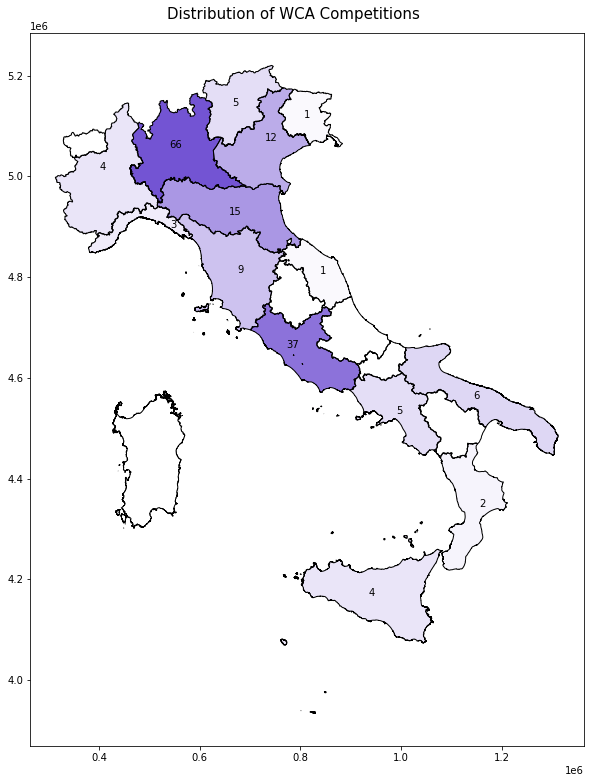

In [46]:
#joining model outputs to the shapefile
#map settings
fig, ax = plt.subplots(figsize = (15,12))
fig.subplots_adjust(top=0.95)
fig.suptitle('Distribution of WCA Competitions',fontsize = 15)
dfr.plot(column = 'competitions', cmap = cmap1,ax=ax, legend=False)
dfr.geometry.boundary.plot(color=None,edgecolor='k',linewidth = 1,ax=ax) 

#adding labels
dfr['coords'] = dfr['geometry'].apply(lambda x: x.representative_point().coords[:])
dfr['coords'] = [coords[0] for coords in dfr['coords']]
for idx, row in dfr.iterrows():
    if row['competitions'] > 0:
        if row['COD_REG'] == 7:
            plt.annotate(text=str(round(row['competitions'],2))[:-2], xy=row['coords'], horizontalalignment='right')
        else:
            plt.annotate(text=str(round(row['competitions'],2))[:-2], xy=row['coords'], horizontalalignment='center')
    else:
        plt.annotate(text = ' ', xy=row['coords'], horizontalalignment='center')
        
        

The map clearly shows an asymmetry in competition distribution. 
The north of Italy had a more active and consistent community throughout the years, and closer delegates. This led to almost half of the total competitions being organized in Lombardia. Since 2022, Lazio has been catching up at a very fast rate (most competitions in 2022 and 2023).

# Events <a name="events"></a>

### Most Events Won

In [47]:
solve = df.query("personCountryId == 'Italy'") #solo italiani
                 
persone = list(persons.query("countryId == 'Italy'")['id'].drop_duplicates())

dict_diff_gold = {}
golds = solve.query("roundTypeId in ('f','c')"
            ).replace([0,-1,-2],np.nan
            ).dropna(axis = 0, subset = ['best']
            ).query("pos == 1") #solo ori

for p in persone:
    nome = list(persons[persons['id'] == p]['name']).pop() #name
    count = golds.query("personId == @p")['eventId'].nunique() #golds
    count2 = solve.query("personId == @p")['eventId'].nunique() #all events
    
    dict_diff_gold[p] = (nome, count, count2)
    
diff_gold = pd.DataFrame.from_dict(dict_diff_gold, orient="index"
                        ).reset_index(drop=False
                        ).rename(columns={"index":"WCAID", 0:"Name", 1:"Different Events Won", 2:"Events Competed In"}
                        ).sort_values(by = ['Different Events Won',"Events Competed In"], ascending = [False,True]
                        ).reset_index(drop = True)

diff_gold.index += 1
diff_gold.head(10)

,WCAID,Name,Different Events Won,Events Competed In
1,2014MAUR06,Lorenzo Mauro,13,18
2,2013FURL01,Mattia Furlan,11,14
3,2007POLI01,Lorenzo Vigani Poli,11,20
4,2013DISA01,Edoardo Disarò,10,17
5,2009CONT01,Giovanni Contardi,9,16
6,2009DIMP01,Mariano D'Imperio,9,20
7,2009ROTA01,Marco Rota,9,20
8,2009MORI05,Paolo Moriello,8,13
9,2011TRON02,Sebastiano Tronto,8,17
10,2017DUMM01,Matteo Dummar,8,18


### Most Events Podiumed

In [48]:
solve = df.query("personCountryId == 'Italy'") #solo italiani
                 
persone = list(persons.query("countryId == 'Italy'")['id'].drop_duplicates())

dict_diff_podiums = {}
podiums = solve.query("roundTypeId in ('f','c')"
            ).replace([0,-1,-2],np.nan
            ).dropna(axis = 0, subset = ['best']
            ).query("pos <= 3") #solo podi

for p in persone:
    nome = list(persons[persons['id'] == p]['name']).pop() #name
    count = podiums.query("personId == @p")['eventId'].nunique() #podiums
    count2 = solve.query("personId == @p")['eventId'].nunique() #all events
    
    dict_diff_podiums[p] = (nome, count, count2)
    
diff_podiums = pd.DataFrame.from_dict(dict_diff_podiums, orient="index"
                        ).reset_index(drop=False
                        ).rename(columns={"index":"WCAID", 0:"Name", 1:"Different Events With Podium", 2:"Events Competed In"}
                        ).sort_values(by = ['Different Events With Podium',"Events Competed In"], ascending = [False,True]
                        ).reset_index(drop = True)

diff_podiums.index += 1
diff_podiums.head(10)

,WCAID,Name,Different Events With Podium,Events Competed In
1,2009ROTA01,Marco Rota,19,20
2,2012NICO02,Alessandro Nicolì,18,18
3,2014MAUR06,Lorenzo Mauro,18,18
4,2009DIMP01,Mariano D'Imperio,17,20
5,2017DUMM01,Matteo Dummar,16,18
6,2008BRAN01,Filippo Brancaleoni,15,16
7,2018CENT02,Giovanni Centili,15,17
8,2009CONT01,Giovanni Contardi,14,16
9,2007POLI01,Lorenzo Vigani Poli,14,20
10,2013FURL01,Mattia Furlan,13,14


### Most popular events - Percentage of Italians with a result in event

In [49]:
solve = df.query("personCountryId == 'Italy'"
            ).replace([0,-1,-2],np.nan
            ).dropna(axis = 0, subset = ['best'])

italians = persons.query("countryId == 'Italy'")['id'].drop_duplicates().count()

dict_percent = {}
for e in event_list:
    count = solve.query("eventId == @e")['personId'].nunique()
    
    dict_percent[e] = truncate(100 * count / italians , 2)
    
epercent = pd.DataFrame.from_dict(dict_percent, orient="index"
                        ).reset_index(drop=False
                        ).rename(columns={"index":"Event", 0:"Percentage of Italians"}
                        ).sort_values(by = 'Percentage of Italians', ascending = False
                        ).reset_index(drop = True)

epercent.index += 1
epercent

,Event,Percentage of Italians
1,333,97.03
2,222,69.17
3,pyram,45.98
4,444,42.14
5,333oh,31.50
6,skewb,26.68
7,555,21.24
8,minx,17.11
9,sq1,13.07
10,clock,9.28


This ranking can also be interpreted as a popularity score among Italians

### Most Common Event Combination

In [50]:
pd.set_option('display.max_colwidth', None)

event_comb = df.query("countryId == 'Italy'"
    )[['competitionId','eventSpecs']
    ].groupby('eventSpecs', as_index=False
    )['competitionId'].nunique(
    ).rename(columns = {'competitionId':'competitions'}
    ).sort_values(['competitions', 'eventSpecs'], ascending=[False, True]
    ).reset_index(drop=True)

event_comb.index +=1
event_comb.head(10)

,eventSpecs,competitions
1,222 333 333bf 333oh 444 pyram skewb,6
2,222 333 333bf 333fm 333ft 333mbf 333oh 444 444bf 555 555bf 666 777 clock minx pyram skewb sq1,4
3,222 333 333bf 333fm 333mbf 333oh 444 444bf 555 555bf 666 777 clock minx pyram skewb sq1,4
4,222 333 333bf 333fm 333ft 333mbf 333oh 444 444bf 555 555bf 666 777 clock magic minx mmagic pyram sq1,3
5,222 333 333bf 333oh 444 555 magic minx,3
6,222 333 333bf 333oh 444 pyram,3
7,333bf 333fm 333mbf 444bf 555bf,3
8,222 333 333bf 333fm 333oh 444 clock pyram,2
9,222 333 333bf 333mbf 333oh 444 444bf 555 555bf 666 777 clock minx pyram skewb sq1,2
10,222 333 333bf 333oh 444 444bf 555 666 777 clock minx pyram skewb sq1,2


The most common event combinations are either fairly standard and newcomer friendly competitions or competitions with all events (e.g. Italian Championships).

### Average Events per competition

In [51]:
compz = df.query("countryId == 'Italy'")

gare = list(set(compz['competitionId']))

dict_avgevents = {}

for c in gare:
    subset = compz.query("competitionId == @c")
    count = subset['eventId'].nunique()
    count2 = subset.groupby('personId')['eventId'].nunique().mean()
    
    dict_avgevents[c] = (count, count2)
    
avgevents = pd.DataFrame.from_dict(dict_avgevents, orient="index"
                        ).reset_index(drop=False
                        ).rename(columns={"index":"Competition", 0:"Events", 1:"Avg Events per Competitor"}
                        ).sort_values(by = 'Avg Events per Competitor', ascending = False
                        ).reset_index(drop = True)

avgevents.index += 1
avgevents.head(10)

,Competition,Events,Avg Events per Competitor
1,ItalianChampionship2010,19,8.600000
2,ClesTooHotForCubing2023,13,8.560000
3,LOLSouthItalianOpen2010,16,8.450000
4,ItalianChampionship2022,16,7.632653
5,ItalianChampionship2019,17,7.413408
6,ItalianChampionship2015,18,7.369565
7,ItalianChampionship2021,16,7.213235
8,ItalianOpen2017,17,6.918919
9,ItalianChampionship2016,17,6.903846
10,ItalianOpen2015,18,6.885714


In [52]:
avgevents.describe()

,Events,Avg Events per Competitor
count,172.000000,172.000000
mean,9.244186,4.732784
std,3.843232,1.347145
min,1.000000,1.000000
25%,7.000000,3.808949
50%,8.000000,4.615646
75%,11.000000,5.647799
max,19.000000,8.600000


Until 2022, competitions in Italy had a mean of 9.27 events each (median at 8) with competitors doing only 4.67 of them on average.<br>
With the addition of 2023's competitions, ...

### Memberships

WCA Memberships are an unofficial status given to competitors that achieved the following milestones:
- <span style="color: #CD7F32"><b>Bronze</b></span>: anyone who has a single result in every official WCA event.
- <span style="color: #C0C0C0"><b>Silver</b></span>: anyone who has a single and average result in every official WCA event.
- <span style="color: #FFD700"><b>Gold</b></span>: anyone who has a single and average result in every official WCA event and has either podiumed at a World Championship, broken a World record, or broken a continental record.
- <span style="color: #E5E4E2"><b>Platinum</b></span>: anyone who has a single and average result in every official WCA event, has podiumed at a World Championship, and has broken a World and Continental record.



#### bronze

In [53]:
bronze = df.query("personCountryId == 'Italy' & best > 0 & eventId not in ('magic', 'mmagic', '333ft', '333mbo')"
            ).groupby("personId"
            )["eventId"].nunique()

bronze = pd.DataFrame(bronze
            ).reset_index(drop = False
            ).query("eventId == 17")['personId'].tolist()

b = persons.query("id in @bronze")[['id','name']].reset_index(drop = True)
b.index +=1
b

,id,name
1,2007POLI01,Lorenzo Vigani Poli
2,2009COLO03,Matteo Colombo
3,2009ROTA01,Marco Rota
4,2011TRON02,Sebastiano Tronto
5,2012NICO02,Alessandro Nicolì
6,2012PLAC01,Gianluca Placenti
7,2014MAUR06,Lorenzo Mauro
8,2015CITT01,Marco Edoardo Cittar
9,2017DUMM01,Matteo Dummar


There are currently no silver, gold or platinum members since no Italian has been able to achieve a 5x5x5 blindfolded mean (yet!).<br>
<b>Marco Rota</b> has a World Record in skewb, so he would jump from bronze directly to gold member.<br>
<b>Sebastiano Tronto</b> has World and Continental records and world championship podiums, so he would jump from bronze directly to platinum.

# SOR & Kinch <a name="SOR"></a>

SOR stands for <i>Sum Of Ranks</i>. Cubers are ranked by the sum of their national rankings in the different WCA categories. Cubers that are good in all events, called <i>all rounders</i>, will have a very low SOR. There are separate SORs for single results and average results.<br>
Kinch ranks improve the SOR by taking the time of the national record into consideration.
For example, Kinch ranks will reward first place if they are very far ahead of the pack while the SOR will only show a difference of 1 place between first and second.

### Sum of Single Ranks

In [54]:
eventi = ['333', '222', '444', '555', '666', '777', '333bf', 
          '333fm', '333oh', 'clock','minx', 'pyram', 'skewb', 'sq1', 
          '444bf', '555bf', '333mbf'] #manually to get wca order

In [55]:
sor_s = ranks_single.query("eventId not in ('333ft', 'magic', 'mmagic', '333mbo') & countryId == 'Italy'"
                    ).pivot_table(index = 'personId', columns = 'eventId', values = 'countryRank'
                    ).reindex(columns = eventi
                    ).apply(lambda col: col.fillna(col.max() + 1), axis = 0
                    ).dropna(axis = 1
                    ).astype("int"
                    ).assign(somma = lambda x: x.sum(axis = 1)
                    ).sort_values("somma")

sor_s.head(10)

eventId,333,222,444,555,666,777,333bf,333fm,333oh,clock,minx,pyram,skewb,sq1,444bf,555bf,333mbf,somma
personId,,,,,,,,,,,,,,,,,,
2014MAUR06,10,14,8,10,12,7,2,8,4,18,2,1,1,9,2,1,1,110
2018CENT02,5,7,11,2,3,6,16,25,14,28,7,6,21,8,12,16,15,202
2012NICO02,6,20,3,6,17,20,44,3,13,24,49,11,8,25,19,15,39,322
2009ROTA01,35,16,46,39,23,27,20,13,46,22,10,13,5,6,10,9,16,356
2019GIOR02,27,2,23,21,15,17,34,18,18,9,21,9,15,30,18,14,73,364
2021MARI04,11,27,13,12,6,14,38,68,5,1,45,8,55,17,27,16,48,411
2017DUMM01,88,36,41,46,39,47,10,15,47,2,51,21,3,4,4,6,10,470
2017TENU01,17,45,25,35,26,32,63,18,24,23,5,67,37,19,23,16,23,498
2018ARNE04,101,41,53,40,36,43,14,37,32,17,16,2,10,13,27,13,18,513


### Sum of Average Ranks

In [56]:
sor_a = ranks_average.query("eventId not in ('333ft', 'magic', 'mmagic', '333mbo') & countryId == 'Italy'"
                    ).pivot_table(index = 'personId', columns = 'eventId', values = 'countryRank'
                    ).reindex(columns = eventi
                    ).apply(lambda col: col.fillna(col.max() + 1), axis = 0
                    ).dropna(axis = 1
                    ).astype("int"
                    ).assign(somma = lambda x: x.sum(axis = 1)
                    ).sort_values("somma")

sor_a.head(10)

eventId,333,222,444,555,666,777,333bf,333fm,333oh,clock,minx,pyram,skewb,sq1,444bf,somma
personId,,,,,,,,,,,,,,,,
2014MAUR06,4,1,9,13,8,7,2,5,2,23,9,3,1,8,4,99
2018CENT02,8,4,12,3,3,6,38,15,17,28,6,5,14,5,4,168
2019GIOR02,35,3,31,25,15,13,33,19,12,14,22,6,13,34,4,279
2018RIMI01,16,8,5,7,17,36,49,60,9,20,12,17,25,3,4,288
2013FURL01,8,52,2,1,1,1,49,60,3,11,2,48,30,55,4,327
2019CORO04,3,12,3,8,10,21,49,60,10,22,20,55,36,28,4,341
2012NICO02,13,63,6,10,18,20,23,11,24,24,49,11,32,45,4,353
2021MARI04,23,77,11,12,7,18,39,35,14,2,45,9,50,14,4,360
2017TENU01,22,26,18,42,23,28,34,12,44,18,4,27,57,18,4,377


### Kinch ranks

In [57]:
kinch = pd.read_html('https://wca.cuber.pro/kinch/persons?regionId=Italy&gender=a&show=100+Persons')[0]

In [58]:
kinch.index += 1
kinch = kinch.drop('Rank', 1)
kinch.head(10)

,Person,Overall,333,222,444,555,666,777,333bf,333fm,333oh,clock,minx,pyram,skewb,sq1,444bf,555bf,333mbf
1,Lorenzo Mauro,83.47,84.96,100.00,85.09,75.78,76.84,72.43,89.15,76.74,98.94,55.07,83.38,72.86,100.00,49.48,98.21,100.00,100.00
2,Sebastiano Tronto,62.92,79.02,49.35,67.43,67.59,47.61,41.87,100.00,100.00,95.05,40.49,59.71,35.19,27.34,11.91,100.00,93.86,53.14
3,Giovanni Centili,61.42,80.00,88.82,82.86,84.48,85.69,73.80,30.57,65.34,75.73,51.51,87.73,71.27,48.37,56.22,32.88,0.00,28.80
4,Matteo Dummar,57.59,58.65,57.41,68.02,60.86,56.25,47.69,40.49,71.73,50.84,100.00,56.33,44.24,47.84,68.95,57.09,47.08,45.58
5,Marco Giordano,53.73,69.10,93.21,73.59,67.53,70.26,66.41,20.81,60.56,80.36,61.60,68.19,64.69,49.89,31.55,19.44,16.19,0.00
6,Mattia Furlan,53.00,80.00,47.34,99.47,100.00,100.00,100.00,13.29,0.00,97.35,62.45,97.25,36.43,43.02,24.34,0.00,0.00,0.00
7,Davide Arnesano,52.78,62.16,60.40,64.11,65.10,58.06,52.34,32.00,62.86,72.86,61.29,74.30,100.00,45.77,44.80,0.00,16.21,24.96
8,Marco Rota,51.82,62.46,52.07,67.91,64.34,64.57,57.47,27.77,72.54,53.44,39.74,74.07,46.56,53.75,53.24,34.67,29.69,26.65
9,Paolo Marino,51.05,74.45,43.64,83.49,78.99,78.81,63.46,19.97,51.56,80.04,94.27,56.04,60.12,36.39,38.81,0.00,0.00,7.86
10,Alessandro Nicolì,50.99,79.21,46.18,91.03,79.49,67.58,62.61,16.93,72.73,71.87,52.95,54.25,55.06,42.29,27.91,18.42,15.07,13.17


### kinch against number of cubers

In [59]:
kinch_countries = pd.read_html('https://wca.cuber.pro/kinch/countries')[0]

In [60]:
pop = pd.DataFrame(persons.query("subid == 1").groupby('countryId')['id'].count()
        ).reset_index(
        ).rename(columns = {'id':'n'}
        ).merge(countries[['id', 'name']], left_on = 'countryId', right_on = 'id'
        ).sort_values(by = 'id', ascending = False)

In [61]:
dict_countries = {
    'Bosnia and Herzegovina':'Bosnia & Herzegovina',
    'Congo':'Congo - Brazzaville',
    'Czech Republic':'Czechia',
    "Côte d'Ivoire":"Côte d'Ivoire",
    'Hong Kong, China':'Hong Kong SAR China',
    'Macau, China':'Macao SAR China',
    'Myanmar':'Myanmar (Burma)',
    'Palestine':'Palestinian Territories',
    'Republic of Korea':'South Korea',
    'Saint Kitts and Nevis':'St. Kitts & Nevis',
    'Trinidad and Tobago':'Trinidad & Tobago'   
}

#bisogna ricontrollare i paesi diversi a fine anno e modificare la mappa di conversione

pop = pop.query("name != 'Democratic Republic of the Congo'") #drop Democratic Republic of the Congo that is not in both lists
pop.replace(dict_countries, inplace = True) #uniform names

df_k = pop.merge(kinch_countries[['Country','Overall']], left_on = 'name', right_on = 'Country')

df_k = df_k.query("n >= 25") #threshold

df_k = df_k[['Country','Overall','n']]
df_k['n'] = np.log10(df_k['n'])



<function matplotlib.pyplot.show(close=None, block=None)>

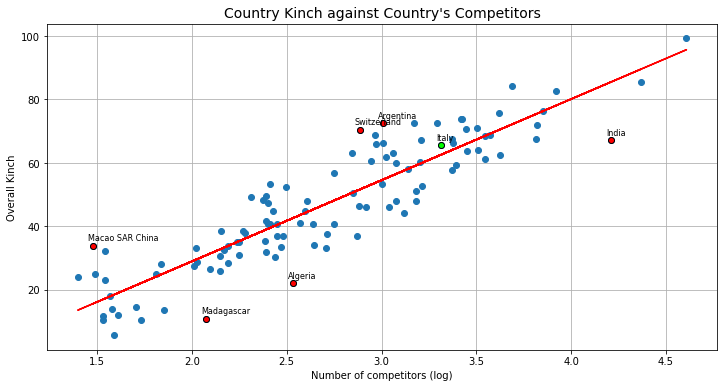

In [62]:
plt.figure
plt.grid(visible = True)
plt.scatter(df_k['n'],df_k['Overall'], zorder = 2)
plt.ylabel('Overall Kinch')
plt.xlabel('Number of competitors (log)')

# Plotting Italy in a different color
special_point_index = df_k.query("Country == 'Italy'").index[0]  # Index of the point you want to highlight
special_point_color = '#00FF00'  # Color for the special point
plt.scatter(df_k.loc[special_point_index, 'n'], df_k.loc[special_point_index, 'Overall'], color=special_point_color, zorder = 4, edgecolor='black', linewidth=1)
plt.annotate("Italy",(df_k.loc[special_point_index, 'n'], df_k.loc[special_point_index, 'Overall']), xytext=(-5, 5),
                 textcoords='offset points', fontsize = 8)

#Plotting Trend line
x = np.array(df_k['n']).reshape(-1, 1)
y = np.array(df_k['Overall']).reshape(-1,1)
regr = linear_model.LinearRegression()
regr.fit(x, y)
y_pred = regr.predict(x)

plt.plot(df_k['n'], y_pred, color = 'red', zorder = 5)

a = regr.coef_[0]
b = regr.intercept_[0]

# filtering
distances = np.abs(df_k['Overall'] - (b + a * df_k['n']))
threshold = np.percentile(distances, 95)
outliers = df_k[distances >= threshold]
plt.scatter(outliers['n'], outliers['Overall'], color='red', edgecolor='black', linewidth=1, zorder = 3)


for _, row in outliers.iterrows():
    plt.annotate(f"{row['Country']}",(row['n'], row['Overall']), xytext=(-5, 5),
                 textcoords='offset points', fontsize = 8)
    

plt.title("Country Kinch against Country's Competitors", fontsize = 14)

plt.show

Italy is on the desirable side of the trend line.<br>
There are countries such as Argentina and Switzerland that have a much better kinch despite having less competitors.

# Results <a name="results"></a>

### Medal table

The medal table uses the <i>weighted</i> criterium: gold is worth more than silver that is worth more than bronze.

In [63]:
solve = df.query("personCountryId == 'Italy' & roundTypeId in ('c','f') & pos <= 3"
            ).replace([0,-1,-2],np.nan
            ).dropna(axis = 0, subset = ['best'])

solve['bronze'] = solve[solve['pos'] == 3].groupby('personId')['personId'].transform('count')
solve['silver'] = solve[solve['pos'] == 2].groupby('personId')['personId'].transform('count')
solve['gold'] = solve[solve['pos'] == 1].groupby('personId')['personId'].transform('count')
solve['podiums'] = solve.groupby('personId')['personId'].transform('count')

In [64]:
medagliere_alltime = solve.groupby(['personId'])[['gold','silver','bronze','podiums']].count(
                        ).reset_index(
                        ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
                        ).drop('id', 1
                        ).rename(columns = {'personId':'WCAID','name':'Name'}
                        ).sort_values(by= ['gold','silver','bronze'], ascending = [False,False,False]
                        ).reset_index(drop = True)

medagliere_alltime.index += 1
medagliere_alltime.head(10)

,WCAID,gold,silver,bronze,podiums,Name
1,2014MAUR06,146,90,56,292,Lorenzo Mauro
2,2013FURL01,113,26,22,161,Mattia Furlan
3,2009CONT01,70,38,43,151,Giovanni Contardi
4,2011TRON02,68,42,25,135,Sebastiano Tronto
5,2009MORI05,67,76,48,191,Paolo Moriello
6,2009IOVA01,66,40,22,128,Massimiliano Iovane
7,2008CIRN01,61,37,21,119,Fabrizio Cirnigliaro
8,2009ROTA01,52,69,80,201,Marco Rota
9,2007POLI01,50,77,98,225,Lorenzo Vigani Poli
10,2009COLO03,40,20,15,75,Matteo Colombo


The following is the same medal table ordered by number of podiums

In [65]:
medagliere_alltime = medagliere_alltime.sort_values(by= ['podiums'], ascending = False
                                        ).reset_index(drop = True)

medagliere_alltime.index += 1
medagliere_alltime.head(10)

,WCAID,gold,silver,bronze,podiums,Name
1,2014MAUR06,146,90,56,292,Lorenzo Mauro
2,2007POLI01,50,77,98,225,Lorenzo Vigani Poli
3,2009ROTA01,52,69,80,201,Marco Rota
4,2009MORI05,67,76,48,191,Paolo Moriello
5,2013FURL01,113,26,22,161,Mattia Furlan
6,2009CONT01,70,38,43,151,Giovanni Contardi
7,2011TRON02,68,42,25,135,Sebastiano Tronto
8,2009IOVA01,66,40,22,128,Massimiliano Iovane
9,2009DIMP01,36,44,47,127,Mariano D'Imperio
10,2012NICO02,24,41,56,121,Alessandro Nicolì


[Lorenzo Mauro](https://www.worldcubeassociation.org/persons/2014MAUR06) recently surpassed both [Mattia Furlan](https://www.worldcubeassociation.org/persons/2013FURL01) for golds and [Lorenzo Vigani Poli](https://www.worldcubeassociation.org/persons/2007POLI01) for total podiums in the medal table.

### Current best world rankings

The following are the best current world rankings of Italians in any event

In [66]:
solve_s = ranks_single.query("countryId == 'Italy'").copy()

solve_s['type'] = ['single' for x in solve_s['personId']]
solve_s = solve_s[['personId', 'name', 'eventId','type', 'best', 'worldRank']
                 ].sort_values(by = ['worldRank', 'name'], ascending = [True, True]
                 ).reset_index(drop = True)

In [67]:
solve_a = ranks_average.query("countryId == 'Italy'").copy()

solve_a['type'] = ['average' for x in solve_a['personId']]
solve_a = solve_a[['personId', 'name', 'eventId','type', 'best', 'worldRank']
                 ].sort_values(by = ['worldRank', 'name'], ascending = [True, True]
                 ).reset_index(drop = True)

In [68]:
solveas = pd.concat([solve_s,solve_a]
            ).sort_values(by = ['worldRank', 'name'], ascending = [True, True]
            ).query("eventId in @current_events"
            ).rename(columns = {'personId':'WCAID', 'name':'Name', 'eventId':'Event'}
            ).reset_index(drop = True)

solveas.index += 1
solveas.head(20)

,WCAID,Name,Event,type,best,worldRank
1,2011TRON02,Sebastiano Tronto,333fm,single,16,1
2,2018RICC02,Alessandro Ricci,sq1,single,400,3
3,2011TRON02,Sebastiano Tronto,333fm,average,2200,10
4,2018RICC02,Alessandro Ricci,sq1,average,624,11
5,2014MAUR06,Lorenzo Mauro,skewb,average,222,19
6,2019MAZZ02,Pietro Mazza,sq1,average,692,22
7,2014MAUR06,Lorenzo Mauro,pyram,single,114,27
8,2014RAPO01,Tommaso Raposio,333fm,single,20,27
9,2018ARNE04,Davide Arnesano,pyram,average,196,31
10,2018RIMI01,Flavio Rimi,sq1,single,527,39


[Sebastiano Tronto](https://www.worldcubeassociation.org/persons/2011TRON02) holds the world record for FMC single and the european record for FMC mean

### Most top 10 rankings

In [69]:
solves = ranks_single.query("countryId == 'Italy' & eventId in @current_events & countryRank <= 10 & countryRank > 0"
                    ).groupby('personId')['countryRank'].count()

solvea = ranks_average.query("countryId == 'Italy' & eventId in @current_events & countryRank <= 10 & countryRank > 0"
                    ).groupby('personId')['countryRank'].count()

totrank = (solves + solvea).fillna(0)

totrank = pd.DataFrame(totrank
            ).reset_index(drop = False
            ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
            ).drop('id', 1
            ).rename(columns = {'countryRank':'Number of Top10 Rankings'})

totrank = totrank[['personId', 'name', 'Number of Top10 Rankings']
                 ].rename(columns = {'personId':'WCAID', 'name':'Name'}
                 ).sort_values(by = 'Number of Top10 Rankings', ascending = False
                ).reset_index(drop = True)

totrank.index += 1
totrank = totrank.astype({"Number of Top10 Rankings": int})
totrank.head(10)

,WCAID,Name,Number of Top10 Rankings
1,2014MAUR06,Lorenzo Mauro,26
2,2018CENT02,Giovanni Centili,16
3,2013FURL01,Mattia Furlan,13
4,2017DUMM01,Matteo Dummar,11
5,2011TRON02,Sebastiano Tronto,10
6,2019SART01,Daniel Sartori,10
7,2017BRAS01,Luca Brasini,9
8,2018RIMI01,Flavio Rimi,8
9,2019CORO04,Giacomo Daniele Corò,8
10,2009ROTA01,Marco Rota,8


Before 2022, out of 17 rankings for single and 16 rankings for average (33 total), [Lorenzo Mauro](https://www.worldcubeassociation.org/persons/2014MAUR06) was among the 10 best Italians in 28 of them.<br>
In 2022 his tally dropped to 26.<br>
In 2023 (?)

### Appearances in top 100 3x3 averages

In [70]:
solve = df.query("eventId == '333' & personCountryId == 'Italy' & average > 0"
            ).sort_values(by = 'average', ascending = True
            ).head(100
            ).groupby('personId')['average'].count()

solve = pd.DataFrame(solve
            ).reset_index(drop = False
            ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
            ).drop('id', 1
            )[['personId','name','average']
            ].rename(columns = {"average":"Top100 averages"}
            ).sort_values(by = 'Top100 averages', ascending = False
            ).reset_index(drop = True)

solve.index += 1
solve

,personId,name,Top100 averages
1,2018LOCA01,Valerio Locatelli,44
2,2019SART01,Daniel Sartori,37
3,2019CORO04,Giacomo Daniele Corò,17
4,2014MAUR06,Lorenzo Mauro,1
5,2017GALE01,Mattia Galentino,1


### Appearances in top 100 3x3 singles

In [71]:
solve = df.query("eventId == '333' & personCountryId == 'Italy'")[
            ['personId','value1','value2','value3','value4','value5']]

solve = pd.concat([solve[['personId','value1']].rename(columns = {'value1':'value'}),
                   solve[['personId','value2']].rename(columns = {'value2':'value'}),
                   solve[['personId','value3']].rename(columns = {'value3':'value'}),
                   solve[['personId','value4']].rename(columns = {'value4':'value'}),
                   solve[['personId','value5']].rename(columns = {'value5':'value'})]
            ).query("value > 0"
            ).sort_values(by = 'value', ascending = True
            ).head(100
            ).groupby('personId')['value'].count()

solve = pd.DataFrame(solve
            ).reset_index(drop = False
            ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
            ).drop('id', 1
            )[['personId','name','value']
            ].rename(columns = {"value":"Top100 singles"}
            ).sort_values(by = 'Top100 singles', ascending = False
            ).reset_index(drop = True)

solve.index += 1
solve

,personId,name,Top100 singles
1,2018LOCA01,Valerio Locatelli,46
2,2019SART01,Daniel Sartori,24
3,2019CORO04,Giacomo Daniele Corò,18
4,2018CENT02,Giovanni Centili,3
5,2011TRON02,Sebastiano Tronto,2
6,2019PAOL02,Federico De Paoli,2
7,2012NICO02,Alessandro Nicolì,1
8,2014MAUR06,Lorenzo Mauro,1
9,2017GALE01,Mattia Galentino,1
10,2020MARC01,Simone Marcellini,1


### Best podium of all time

In [72]:
solve = df.query("countryId == 'Italy' & eventId == '333' & roundTypeId in ('c','f') & pos <= 3"
            ).replace([0,-1,-2],np.nan) # via dnf e cose strane

gare = list(set(solve['competitionId']))

dict_bestpodiums = {}

for c in gare:
    subset = solve.query("competitionId == @c").sort_values(by = 'pos', ascending = True)
    count = subset['average'].sum()
    dict_bestpodiums[c] = (count, subset.iloc[0,6], subset.iloc[0,5], subset.iloc[1,6], subset.iloc[1,5], subset.iloc[2,6], subset.iloc[2,5])
    
bestpodiums = pd.DataFrame.from_dict(dict_bestpodiums, orient="index"
                        ).reset_index(drop=False
                        ).rename(columns={"index":"Competition", 0:"Best Podium", 1:"First", 2:"Average1", 3:"Second", 4:"Average2", 5:"Third", 6:"Average3",}
                        ).sort_values(by = 'Best Podium', ascending = True
                        ).reset_index(drop = True)

bestpodiums['Best Podium'] = bestpodiums['Best Podium'] / 100
bestpodiums['Average1'] = bestpodiums['Average1'] / 100
bestpodiums['Average2'] = bestpodiums['Average2'] / 100
bestpodiums['Average3'] = bestpodiums['Average3'] / 100

bestpodiums.index += 1
bestpodiums.head(10)

,Competition,Best Podium,First,Average1,Second,Average2,Third,Average3
1,ItsSarzanaOclock2023,21.28,Valerio Locatelli,6.80,Daniel Sartori,7.14,Juliette Sébastien,7.34
2,LodiTimeTrial2023,21.55,Juliette Sébastien,6.89,Daniel Sartori,7.30,Valerio Locatelli,7.36
3,ClesTooHotForCubing2023,21.88,Valerio Locatelli,6.70,Daniel Sartori,7.04,Giacomo Daniele Corò,8.14
4,NexCubeItalianOpen2023,22.24,Daniel Sartori,7.14,Giacomo Daniele Corò,7.20,Valerio Locatelli,7.90
5,EretumIIIWCWarmup2023,22.45,Valerio Locatelli,6.90,Daniel Sartori,7.50,Giovanni Centili,8.05
6,BolognaSummerOpen2021,22.57,Juliette Sébastien,7.20,Valerio Locatelli,7.52,Lucas Déglise,7.85
7,EretumIV2023,23.05,Daniel Sartori,7.19,Valerio Locatelli,7.35,Alessandro Nicolì,8.51
8,PaladiamanteOpen2022,23.15,Valerio Locatelli,7.42,Juliette Sébastien,7.45,Nicolas Gertner Kilian,8.28
9,BolognaBackfromHolidays2021,23.54,Valerio Locatelli,7.15,Juliette Sébastien,8.05,Daniel Sartori,8.34
10,ItalianChampionship2022,23.56,Valerio Locatelli,6.72,Davide Camilleri,8.10,Daniel Sartori,8.74


The best all-italian podium is ranked 3rd among the fastest podiums registered on Italian soil.

### Best first Average

In [73]:
bestfirst = df.query("personCountryId == 'Italy' & eventId == '333'"
            ).replace([0,-1,-2],np.nan
            ).groupby('personId')['average'].nth(0)

bestfirst = pd.DataFrame(bestfirst
                ).reset_index(
                ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
                ).drop('id', 1)

bestfirst = bestfirst[['personId', 'name', 'average']].dropna()
bestfirst['average'] = bestfirst['average'].astype({"average": int}) / 100
bestfirst = bestfirst.rename(columns = {'personId':'WCAID','name':'Name', 'average':'Best First Average'}
                    ).dropna(
                    ).sort_values(by = 'Best First Average', ascending = True
                    ).reset_index(drop = True)

bestfirst.index += 1
bestfirst.head(10)

,WCAID,Name,Best First Average
1,2022RIBE02,Vittorio Ribechini,10.07
2,2019CAMI03,Davide Camilleri,10.84
3,2023CATA06,Giuseppe Catalano,11.32
4,2012MURC01,Davide Murciano,11.41
5,2021NARB01,Dario Angelo Narbone,11.66
6,2023MORA11,Gabriele Mora,12.10
7,2021ITAL02,Manfredi Italiano,12.49
8,2022FABR03,Andrea Fabrizio,12.60
9,2021SALE01,Sofia Saletnich,12.66
10,2022MANT03,Alberto Mantovani,12.67


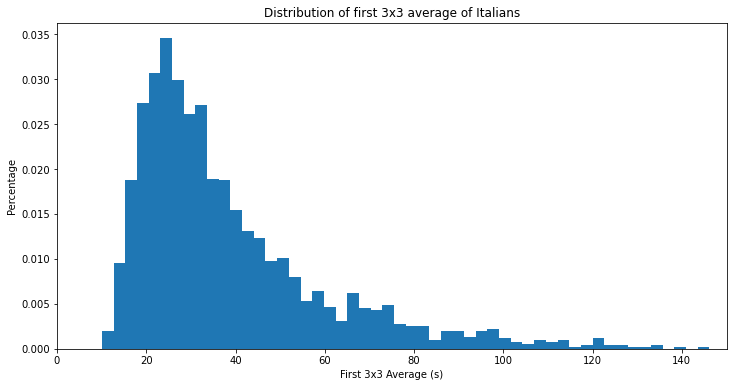

In [74]:
plt.hist(bestfirst['Best First Average'], density=True, bins=100)  # density=False would make counts
plt.ylabel('Percentage')
plt.xlim(0,150)
plt.xlabel('First 3x3 Average (s)')
plt.title('Distribution of first 3x3 average of Italians')
plt.show()

In [75]:
bestfirst['Best First Average'].describe()

count    1958.000000
mean       39.943534
std        26.143723
min        10.070000
25%        23.660000
50%        32.260000
75%        47.342500
max       271.780000
Name: Best First Average, dtype: float64

On average, Italians at the first competitions score a NNNN 3x3 average (median is lower: MMMM)

### Male vs Female averages distribution


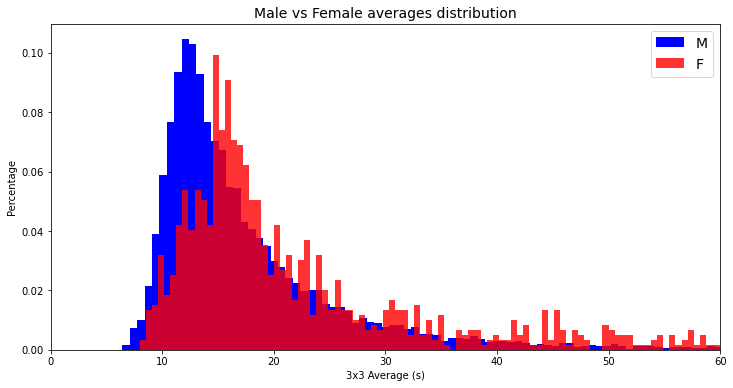

In [76]:
f = list(persons.query("gender == 'f' & countryId == 'Italy'")['id']) #female competitors

avg_m = list(df.query("personCountryId == 'Italy' & eventId == '333' & average > 0 & personId not in @f")['average']/100)
avg_f = list(df.query("personCountryId == 'Italy' & eventId == '333' & average > 0 & personId in @f")['average']/100)

plt.figure
plt.hist(avg_m, density = True, bins = 400, color = 'b')  # density=False would make counts
plt.hist(avg_f, density = True, bins = 400, color = 'r', alpha = 0.8, zorder = 3)
plt.ylabel('Percentage')
plt.xlim(0,60)
plt.xlabel('3x3 Average (s)')
plt.title('Male vs Female averages distribution', fontsize = 14)
plt.legend(['M', 'F'], fontsize = 14)
plt.show()

### Single against Average

In [77]:
points = ranks_single.query("countryId == 'Italy' & eventId == '333'"
                    ).merge(ranks_average.query("countryId == 'Italy' & eventId == '333' & best > 0 & best <= 3000"), left_on = "personId", right_on = "personId")

In [78]:
#Trendline

x = np.array(points['best_y']/100).reshape(-1, 1)
y = np.array(points['best_x']/100).reshape(-1,1)
regr = linear_model.LinearRegression()
regr.fit(x, y)
y_pred = regr.predict(x)

print(regr.coef_, regr.intercept_)

[[0.84024465]] [-0.17263632]


$$\textit{single}=-0.142 + 0.841\cdot\textit{average}$$ ^ da sistemare a fine anno con i coeff giusti

(0.0, 30.0)

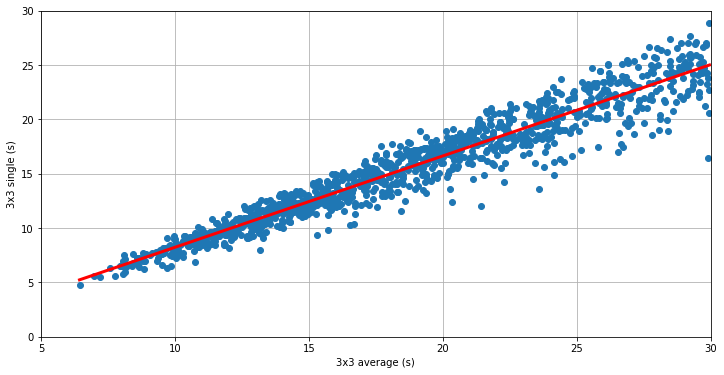

In [79]:
plt.figure
plt.scatter(points['best_y']/100,points['best_x']/100, zorder = 2)
plt.plot(x, y_pred, color="red", linewidth=3, zorder = 3)
plt.grid(visible = True)
plt.xlabel('3x3 average (s)')
plt.ylabel('3x3 single (s)')
plt.xlim(5,30)
plt.ylim(0,30)

# Records <a name="records"></a>

### Italian National Records

In [80]:
nrs = df.query("personCountryId == 'Italy' & regionalSingleRecord in ('NR', 'CR', 'WR')"
              )[['personId','personName','eventId','best','competitionId','year','month','day']].copy()
nra = df.query("personCountryId == 'Italy' & regionalAverageRecord in ('NR', 'CR', 'WR')"
              )[['personId','personName','eventId','average','competitionId','year','month','day']].copy()

nrs['date'] = pd.to_datetime(nrs[['year','month','day']])
nra['date'] = pd.to_datetime(nra[['year','month','day']])

nrs = nrs.sort_values(by = ['date','best'], ascending = [False, False])
nra = nra.sort_values(by = ['date','average'], ascending = [False, False])

dict_nrs = {}
dict_nra = {}

eventi = ['333', '222', '444', '555', '666', '777', '333bf', 
          '333fm', '333oh', 'clock','minx', 'pyram', 'skewb', 'sq1', 
          '444bf', '555bf', '333mbf'] #manually to get wca order

#simple query to get the desired result. The problem is that I also want WCA event order, competitionId and date of the record
#nrs = ranks_single.query("countryRank == 1 & countryId == 'Italy' & eventId in @eventi"
#                        )[['personId','name','eventId','best']].reset_index(drop = True)

for e in eventi:
    buffer = nrs.query("eventId == @e")
    dict_nrs[e] = (buffer.iloc[0,0], buffer.iloc[0,1], buffer.iloc[0,3], buffer.iloc[0,4], buffer.iloc[0,8])
    
nrs = pd.DataFrame.from_dict(dict_nrs, orient="index"
                            ).reset_index(drop=False
                            ).rename(columns = {"index":"event", 0:"personId", 1: "personName", 2: "Result", 3:"competitionId", 4:"date"})

for e in eventi:
    buffer = nra.query("eventId == @e")
    if buffer.shape[0]>0:
        dict_nra[e] = (buffer.iloc[0,0], buffer.iloc[0,1], buffer.iloc[0,3], buffer.iloc[0,4], buffer.iloc[0,8])
    else:
        continue
    
nra = pd.DataFrame.from_dict(dict_nra, orient="index"
                            ).reset_index(drop=False
                            ).rename(columns = {"index":"event", 0:"personId", 1: "personName", 2: "Result", 3:"competitionId", 4:"date"})



#### singles

In [81]:
nrs

,event,personId,personName,Result,competitionId,date
0,333,2018LOCA01,Valerio Locatelli,479,ItsSarzanaOclock2023,2023-05-27
1,222,2009KASE02,Christian Kaserer,69,TrentinOpen2011,2011-11-12
2,444,2019CORO04,Giacomo Daniele Corò,2486,NexCubeItalianOpen2023,2023-06-24
3,555,2013FURL01,Mattia Furlan,4538,SalzburgOpen2020,2020-02-01
4,666,2013FURL01,Mattia Furlan,8666,ItalianChampionship2019,2019-11-01
5,777,2013FURL01,Mattia Furlan,12969,RoadtoICBologna2019,2019-09-21
6,333bf,2011TRON02,Sebastiano Tronto,1948,WC2019,2019-07-11
7,333fm,2011TRON02,Sebastiano Tronto,16,FMC2019,2019-06-15
8,333oh,2018LOCA01,Valerio Locatelli,903,EretumIV2023,2023-08-26
9,clock,2021MARI04,Paolo Marino,450,MontemurloSpeedcubing2023,2023-06-17


#### averages

In [82]:
nra

,event,personId,personName,Result,competitionId,date
0,333,2018LOCA01,Valerio Locatelli,644,NexCubeItalianOpen2023,2023-06-24
1,222,2014MAUR06,Lorenzo Mauro,151,ItalianChampionship2021,2021-10-30
2,444,2009CONT01,Giovanni Contardi,2842,RoadtoICMilano2019,2019-10-19
3,555,2013FURL01,Mattia Furlan,5123,SalzburgOpen2020,2020-02-01
4,666,2013FURL01,Mattia Furlan,9427,ItalianChampionship2019,2019-11-01
5,777,2013FURL01,Mattia Furlan,13619,SalzburgOpen2020,2020-02-01
6,333bf,2011TRON02,Sebastiano Tronto,2442,PoliMiMentalBreakdown2019,2019-03-16
7,333fm,2011TRON02,Sebastiano Tronto,2200,FMC2019,2019-06-15
8,333oh,2018LOCA01,Valerio Locatelli,1211,LodiTimeTrial2023,2023-04-29
9,clock,2017DUMM01,Matteo Dummar,494,MontemurloSpeedcubing2023,2023-06-17


### Oldest Standing Records

In [83]:
nrs['type'] = ['single' for x in nrs['Result']]
nra['type'] = ['average' for x in nra['Result']]

old = pd.concat([nrs,nra]).sort_values(by = 'date').reset_index(drop = True)
old.index +=1

old['days'] = (pd.Timestamp.today()-old['date']).apply(lambda x: x.days)

old.head(10)

,event,personId,personName,Result,competitionId,date,type,days
1,222,2009KASE02,Christian Kaserer,69,TrentinOpen2011,2011-11-12,single,4311
2,444bf,2015CITT01,Marco Edoardo Cittar,32696,ItalianChampionship2017,2017-12-16,average,2085
3,333bf,2011TRON02,Sebastiano Tronto,2442,PoliMiMentalBreakdown2019,2019-03-16,average,1630
4,444bf,2011TRON02,Sebastiano Tronto,15919,MentalBreakdownCapelle2019,2019-05-03,single,1582
5,333fm,2011TRON02,Sebastiano Tronto,2200,FMC2019,2019-06-15,average,1539
6,333fm,2011TRON02,Sebastiano Tronto,16,FMC2019,2019-06-15,single,1539
7,333bf,2011TRON02,Sebastiano Tronto,1948,WC2019,2019-07-11,single,1513
8,777,2013FURL01,Mattia Furlan,12969,RoadtoICBologna2019,2019-09-21,single,1441
9,444,2009CONT01,Giovanni Contardi,2842,RoadtoICMilano2019,2019-10-19,average,1413
10,666,2013FURL01,Mattia Furlan,8666,ItalianChampionship2019,2019-11-01,single,1400


### Italian World and Continental records

In [84]:
records = df[df['personCountryId'] == 'Italy'] #solo italiani
records = records[(records['regionalSingleRecord'] == 'WR') | (records['regionalAverageRecord'] == 'WR')|(records['regionalSingleRecord'] == 'ER') | (records['regionalAverageRecord'] == 'ER')]
records = records[['personId','personName','competitionId','year','eventId','best','average','regionalSingleRecord','regionalAverageRecord']]
records.loc[records['regionalSingleRecord']=='NR', 'regionalSingleRecord'] = np.nan
records.loc[records['regionalAverageRecord']=='NR', 'regionalAverageRecord'] = np.nan
            

In [85]:
recordsg = records.groupby('year')['regionalSingleRecord'].apply(lambda x: (x=='WR').sum()).reset_index(name='WRcount') + records.groupby('year')['regionalAverageRecord'].apply(lambda x: (x=='WR').sum()).reset_index(name='WRcount')
ers = records.groupby('year')['regionalSingleRecord'].apply(lambda x: (x=='ER').sum()).reset_index(name='ERcount') + records.groupby('year')['regionalAverageRecord'].apply(lambda x: (x=='ER').sum()).reset_index(name='ERcount')
recordsg['ERcount'] = ers['ERcount']
recordsg['year'] = recordsg['year'] / 2
extra = [(2003, 0, 0), (2004, 0, 0), (2005, 0, 0), (2006, 0, 0), (2007, 0, 0), (2008, 0, 0), (2009, 0, 0), (2020, 0, 0), (2021, 0, 0), (2022, 0, 0), (2023,0,0)]
recordsg = pd.concat([recordsg,pd.DataFrame(extra, columns = recordsg.columns)], axis = 0).reset_index(drop = True)
recordsg = recordsg.astype(int)
recordsg = recordsg.sort_values(by = 'year')

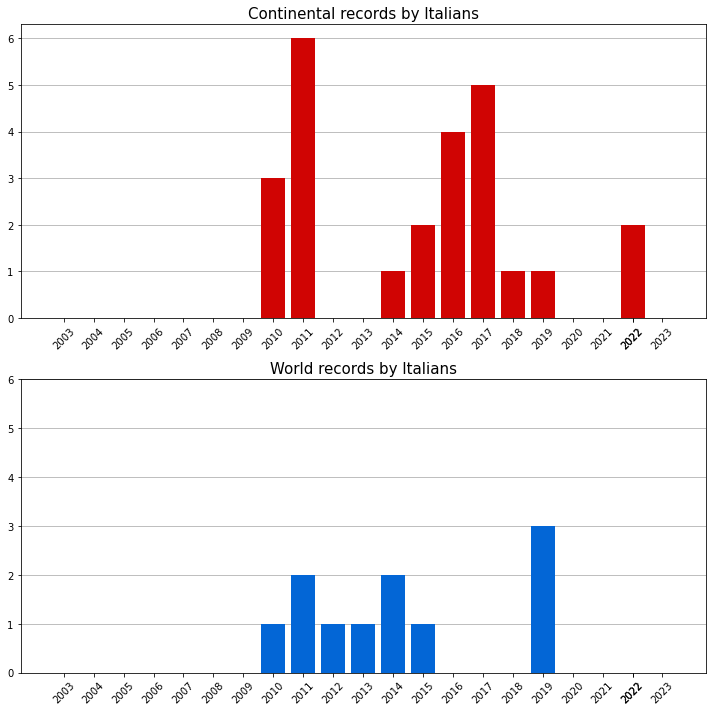

In [86]:
fig = plt.figure(figsize = (10,10))

plt.subplot(2, 1, 1)
plt.bar(recordsg['year'], recordsg['ERcount'], color = '#D00403', zorder=3);
plt.xticks(recordsg['year']);
plt.xticks(rotation=45);
plt.title('Continental records by Italians', fontsize = 15);
plt.grid(axis = 'y')

plt.subplot(2, 1, 2)
plt.bar(recordsg['year'], recordsg['WRcount'], color = '#0366D6', zorder=3);
plt.xticks(recordsg['year']);
plt.xticks(rotation=45);
plt.title('World records by Italians', fontsize = 15);
plt.ylim(0,6)
plt.grid(axis = 'y')

plt.tight_layout()

### Evolution of 3x3 NRs

In [87]:
nr = df[df['personCountryId'] == 'Italy'] #solo italiani

nrs = nr[((nr['regionalSingleRecord'] == 'NR')|(nr['regionalSingleRecord'] == 'ER')|(nr['regionalSingleRecord'] == 'WR')) & (nr['eventId'] == '333')].copy(deep = True)
nrs['date'] = pd.to_datetime(nrs[['year','month','day']])
nrs = nrs[['personId','personName','best','date']].sort_values(by = ['date','best'], ascending = [True,False])
nrs = nrs.rename(columns = {'personId':'WCAID','personName':'Name','best':'NR single'})
nrs['NR single'] = nrs['NR single'] / 100

nra = nr[((nr['regionalAverageRecord'] == 'NR')|(nr['regionalAverageRecord'] == 'ER')|(nr['regionalAverageRecord'] == 'WR')) & (nr['eventId'] == '333')].copy(deep = True)
nra['date'] = pd.to_datetime(nra[['year','month','day']])
nra = nra[['personId','personName','average','date']].sort_values(by = ['date','average'], ascending = [True,False])
nra = nra.rename(columns = {'personId':'WCAID','personName':'Name','average':'NR average'})
nra['NR average'] = nra['NR average'] / 100

wrs = df[(df['regionalSingleRecord'] == 'WR') & (df['eventId'] == '333')].copy(deep = True)
wrs['date'] = pd.to_datetime(wrs[['year','month','day']])
wrs = wrs[['personId','personName','best','date']].sort_values(by = ['date','best'], ascending = [True,False])
wrs = wrs.rename(columns = {'personId':'WCAID','personName':'Name','best':'WR single'})
wrs['WR single'] = wrs['WR single'] / 100

wra = df[(df['regionalAverageRecord'] == 'WR') & (df['eventId'] == '333')].copy(deep = True)
wra['date'] = pd.to_datetime(wra[['year','month','day']])
wra = wra[['personId','personName','average','date']].sort_values(by = ['date','average'], ascending = [True,False])
wra = wra.rename(columns = {'personId':'WCAID','personName':'Name','average':'WR average'})
wra['WR average'] = wra['WR average'] / 100

In [88]:
today = pd.to_datetime(pd.Timestamp.today()) + pd.Timedelta(weeks=8)

todaynrs = [(nrs.iloc[-1,0], nrs.iloc[-1,1], nrs.iloc[-1,2], today)]
todaynra  = [(nra.iloc[-1,0], nra.iloc[-1,1], nra.iloc[-1,2], today)]
todaywrs = [(wrs.iloc[-1,0], wrs.iloc[-1,1], wrs.iloc[-1,2], today)]
todaywra = [(wra.iloc[-1,0], wra.iloc[-1,1], wra.iloc[-1,2], today)]

nrs = pd.concat([nrs, pd.DataFrame(todaynrs, columns = nrs.columns)], axis = 0) #add data to extend the lines in the plot
nra = pd.concat([nra, pd.DataFrame(todaynra, columns = nra.columns)], axis = 0)
wrs = pd.concat([wrs, pd.DataFrame(todaywrs, columns = wrs.columns)], axis = 0)
wra = pd.concat([wra, pd.DataFrame(todaywra, columns = wrs.columns)], axis = 0)

nrs = nrs.reset_index(drop = True)
nra = nra.reset_index(drop = True)
wrs = wrs.reset_index(drop = True)
wra = wra.reset_index(drop = True)

History of national record singles

In [89]:
nrs[:-1] #-1 to avoid duplicate row at the end

,WCAID,Name,NR single,date
0,1982ROME01,Giuseppe Romeo,28.11,1982-06-05
1,2007CHIM01,Giulio Chiminelli,23.28,2007-05-26
2,2007CHIM01,Giulio Chiminelli,16.78,2007-05-26
3,2007POLI01,Lorenzo Vigani Poli,14.96,2008-06-21
4,2008ROSS01,Paolo Rosson,14.93,2008-11-08
5,2008ROSS01,Paolo Rosson,12.47,2008-11-08
6,2009BEVA01,Stefano Bevacqua,12.08,2009-09-19
7,2009IOVA01,Massimiliano Iovane,11.02,2009-10-09
8,2008BRAN01,Filippo Brancaleoni,9.28,2009-12-29
9,2009CONT01,Giovanni Contardi,8.96,2010-05-09


History of national record averages

In [90]:
nra[:-1]

,WCAID,Name,NR average,date
0,2007SCIB01,Emanuele Scibilia,25.96,2007-05-26
1,2007CHIM01,Giulio Chiminelli,20.90,2007-05-26
2,2007POLI01,Lorenzo Vigani Poli,19.67,2008-02-02
3,2008ROSS01,Paolo Rosson,19.25,2008-06-21
4,2007POLI01,Lorenzo Vigani Poli,17.40,2008-06-21
5,2008ROSS01,Paolo Rosson,17.39,2008-11-08
6,2007POLI01,Lorenzo Vigani Poli,16.76,2008-11-08
7,2007POLI01,Lorenzo Vigani Poli,16.70,2009-02-14
8,2007POLI01,Lorenzo Vigani Poli,16.44,2009-08-08
9,2007POLI01,Lorenzo Vigani Poli,15.34,2009-08-08


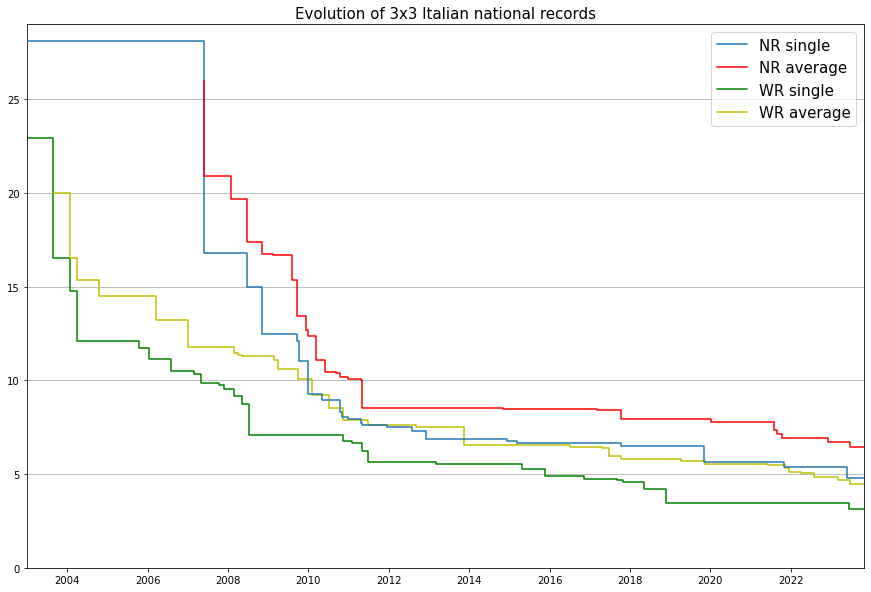

In [91]:
plt.figure(figsize = (15,10))
plt.step(nrs['date'],nrs['NR single'], zorder=3, where = 'post');
plt.step(nra['date'],nra['NR average'], color = 'r', zorder=3, where = 'post');
plt.step(wrs['date'],wrs['WR single'], color = 'g', where = 'post');
plt.step(wra['date'],wra['WR average'], color = 'y', where = 'post');
plt.title('Evolution of 3x3 Italian national records', fontsize=15);
plt.legend(['NR single','NR average', 'WR single','WR average'], fontsize=15)
plt.ylim(0,29)
plt.xlim(pd.to_datetime('2003-01-01'),today)

plt.grid(axis = 'y')

The current national records are held by [Valerio Locatelli](https://www.worldcubeassociation.org/persons/2018LOCA01).

# Italian Championship <a name="IC"></a>

### Locations

In [92]:
cities = df.query("competitionId in @IC & cityName != 'Multiple cities'")[['competitionId', 'year', 'cityName','latitude','longitude']].drop_duplicates()

#convert latitude to decimal
cities['latitude'] = cities['latitude'] / 1000000
cities['longitude'] = cities['longitude'] / 1000000

Text(0.5, 1.0, 'Location of Italian Championships')

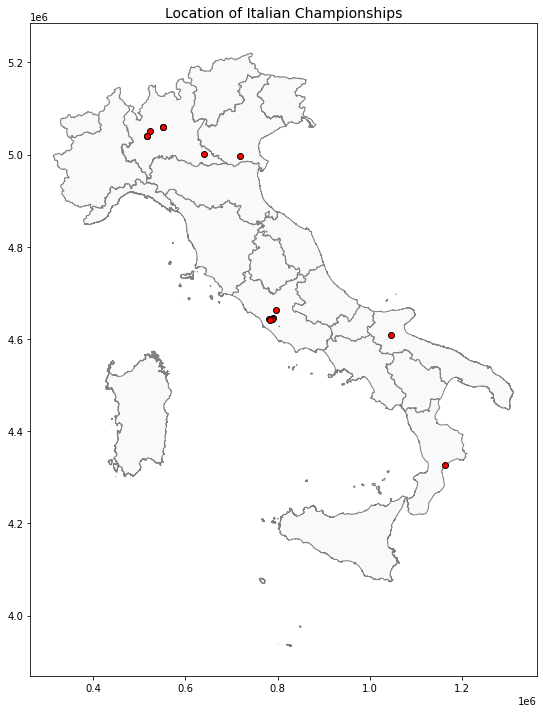

In [93]:
#Load shapefile
italy = gpd.read_file(os.path.join("Limiti01012022/Reg01012022",'Reg01012022_WGS84.shp'))

#polot bg map
fig, ax = plt.subplots(figsize=(15,12))
italy.plot(ax=ax, color = '#f9f9f9', edgecolor = 'grey')

#create points in a default crs
crs = 'epsg:4326'
geometry = [Point(xy) for xy in zip(cities['longitude'], cities['latitude'])]
gdf = gpd.GeoDataFrame(cities, #specify our data
                          crs=crs, #specify our coordinate reference system
                          geometry=geometry) #specify the geometry list we created

#get crs of map
#italy.crs -> EPSG32632
with open(os.path.join("Limiti01012022/Reg01012022",'Reg01012022_WGS84.prj')) as prj_file:
    crs = prj_file.read()

#convert points crs to map crs
gdf2 = gdf.to_crs(crs)
gdf2.plot(ax = ax, color = 'r', edgecolor = 'k', linewidth = 1)

#beautify
plt.title('Location of Italian Championships', fontsize = 14)


Cubing Italy has always tried to organize an equal amount of Italian Championships in the North and In the South + Rome. This is reflected by the data.

### List of Champions (3x3x3)

In [94]:
champs333 = df.query("competitionId in @IC & roundTypeId in ('c','f') & eventId == '333' & best > 0 & personCountryId == 'Italy'"
    ).sort_values(by = 'pos'
    ).groupby('competitionId').nth(0).reset_index(drop = False)[['eventId','personId','personName','year']
    ].sort_values(by = 'year').reset_index(drop = True)

champs333.index += 1
champs333

,eventId,personId,personName,year
1,333,2007CHIM01,Giulio Chiminelli,2007
2,333,2007POLI01,Lorenzo Vigani Poli,2008
3,333,2009IOVA01,Massimiliano Iovane,2009
4,333,2009CONT01,Giovanni Contardi,2010
5,333,2009CONT01,Giovanni Contardi,2011
6,333,2009CONT01,Giovanni Contardi,2012
7,333,2009CONT01,Giovanni Contardi,2013
8,333,2009CONT01,Giovanni Contardi,2014
9,333,2011BARB03,Nicola Barbaro,2015
10,333,2009MORI05,Paolo Moriello,2016


#### winners

In [95]:
w = pd.DataFrame(champs333.groupby('personId')['personName'].count()).reset_index(drop = False
            ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
            ).drop('id', 1
            ).rename(columns = {'personName':'wins'}
            )[['personId','name','wins']
            ].sort_values(by = 'wins', ascending = False
            ).reset_index(drop = True)

w['years'] = [", ".join([str(item) for item in champs333.query("personId == @d")['year']]) for d in w['personId']]
w.index += 1
w

,personId,name,wins,years
1,2009CONT01,Giovanni Contardi,5,"2010, 2011, 2012, 2013, 2014"
2,2011BARB03,Nicola Barbaro,2,"2015, 2018"
3,2018LOCA01,Valerio Locatelli,2,"2021, 2022"
4,2007CHIM01,Giulio Chiminelli,1,2007
5,2007POLI01,Lorenzo Vigani Poli,1,2008
6,2009IOVA01,Massimiliano Iovane,1,2009
7,2009MORI05,Paolo Moriello,1,2016
8,2013FURL01,Mattia Furlan,1,2017
9,2017GALE01,Mattia Galentino,1,2019


### Current Italian Champions

In [96]:
last_championship = ['ItalianChampionship2022','FMCItaly2022']
eventi = ['333', '222', '444', '555', '666', '777', '333bf', 
          '333fm', '333oh', 'clock','minx', 'pyram', 'skewb', 'sq1', 
          '444bf', '555bf', '333mbf'] #manually to get wca order

champs = df.query("competitionId in @last_championship & roundTypeId in ('c','f') & eventId in @eventi & best > 0 & personCountryId == 'Italy'"
    ).sort_values(by = 'pos'
    ).groupby('eventId').nth(0).reset_index(drop = False)[['eventId','personId','personName']]

champs.sort_values(by="eventId", key=lambda column: column.map(lambda e: eventi.index(e))).reset_index(drop = True) #wca order


,eventId,personId,personName
0,333,2018LOCA01,Valerio Locatelli
1,222,2014MAUR06,Lorenzo Mauro
2,444,2012NICO02,Alessandro Nicolì
3,555,2018CENT02,Giovanni Centili
4,666,2017BRAS01,Luca Brasini
5,777,2017BRAS01,Luca Brasini
6,333bf,2014MAUR06,Lorenzo Mauro
7,333fm,2011TRON02,Sebastiano Tronto
8,333oh,2018LOCA01,Valerio Locatelli
9,clock,2017DUMM01,Matteo Dummar


### Medal table (all events)

In [97]:
solve = df.query("personCountryId == 'Italy' & roundTypeId in ('c','f') & competitionId in @IC & best > 0").copy()

solve['nr_rank'] = solve.groupby(['competitionId','eventId'])['pos'].rank(method = 'min')

solve['bronze'] = solve[solve['nr_rank'] == 3].groupby('personId')['personId'].transform('count')
solve['silver'] = solve[solve['nr_rank'] == 2].groupby('personId')['personId'].transform('count')
solve['gold'] = solve[solve['nr_rank'] == 1].groupby('personId')['personId'].transform('count')
solve['podiums'] = solve.query('nr_rank <= 3').groupby('personId')['nr_rank'].transform('count')

In [98]:
medagliere_ic = solve.groupby(['personId'])[['gold','silver','bronze','podiums']].count(
                        ).reset_index(
                        ).merge(persons[['id','name']], how = 'left', left_on = 'personId', right_on = 'id'
                        ).drop('id', 1
                        ).rename(columns = {'personId':'WCAID','name':'Name'}
                        ).sort_values(by= ['gold','silver','bronze'], ascending = [False,False,False]
                        ).reset_index(drop = True)

medagliere_ic.index += 1
medagliere_ic.head(10)

,WCAID,gold,silver,bronze,podiums,Name
1,2014MAUR06,23,18,11,52,Lorenzo Mauro
2,2009CONT01,18,12,10,40,Giovanni Contardi
3,2011TRON02,18,9,3,30,Sebastiano Tronto
4,2013FURL01,17,2,4,23,Mattia Furlan
5,2009DIMP01,11,10,7,28,Mariano D'Imperio
6,2008CIRN01,11,4,4,19,Fabrizio Cirnigliaro
7,2007POLI01,10,20,15,45,Lorenzo Vigani Poli
8,2009SANT01,10,6,2,18,Simone Santarsiero
9,2009IOVA01,9,8,6,23,Massimiliano Iovane
10,2007CHIM01,7,1,1,9,Giulio Chiminelli


### Streaks

In [99]:
champs = df.query("competitionId in @IC & roundTypeId in ('c','f') & best > 0 & personCountryId == 'Italy'"
    ).sort_values(by = 'pos'
    ).groupby(['competitionId','eventId']).nth(0).reset_index(drop = False)[['eventId','personId','personName','year']
    ].sort_values(by = ['personId','year']).reset_index(drop = True)

results = champs.sort_values(by=['eventId','year'])

results['streak_id'] = (results['personId'] != results['personId'].shift(1)).cumsum()

max_streaks = results.groupby(['eventId', 'personId', 'personName', 'streak_id']).size().reset_index(name='count')
max_streaks = max_streaks.groupby(['eventId', 'personId', 'personName'])['count'].max().reset_index()
max_streaks.reset_index(drop=True, inplace=True)

max_streaks = max_streaks.rename(columns = {'personName_x':'personName', 'count':'consecutive_wins'}
                        ).sort_values(by = ['consecutive_wins','eventId'], ascending = [False,True]
                        ).reset_index(drop = True)

max_streaks.index += 1

max_streaks[['personId','personName','eventId','consecutive_wins']].head(20)

,personId,personName,eventId,consecutive_wins
1,2009DIMP01,Mariano D'Imperio,minx,6
2,2009CONT01,Giovanni Contardi,333,5
3,2008CIRN01,Fabrizio Cirnigliaro,333mbf,5
4,2009CONT01,Giovanni Contardi,444,5
5,2011TRON02,Sebastiano Tronto,333bf,4
6,2014MAUR06,Lorenzo Mauro,333mbf,4
7,2009CONT01,Giovanni Contardi,555,4
8,2009IOVA01,Massimiliano Iovane,666,4
9,2011TRON02,Sebastiano Tronto,333fm,3
10,2008CIRN01,Fabrizio Cirnigliaro,555bf,3


# Relays <a name="relays"></a>

A series of relay times calculated with official personal records

### 2-7 "Official" Releay

2-7 relay is all NxN events recognized by the WCA

In [100]:
eventi = ['222', '333', '444', '555', '666', '777']

relay = ranks_single.query("eventId in @eventi & countryId == 'Italy'"
                    ).pivot_table(index = 'name', columns = 'eventId', values = 'best'
                    ).reindex(columns = eventi
                    ).apply(lambda col: col.fillna(col.max() + 1), axis = 0
                    ).dropna(axis = 1
                    ).astype("int"
                    ).assign(somma = lambda x: x.sum(axis = 1)
                    ).sort_values("somma"
                    ).apply(lambda col: col.apply(lambda x:timeconvert(x)))

relay.head(10)

eventId,222,333,444,555,666,777,somma
name,,,,,,,
Mattia Furlan,1.61,6.68,25.25,45.38,1:26.66,2:09.69,4:55.27
Luca Brasini,1.42,6.91,28.30,52.42,1:40.65,2:34.77,5:44.47
Giovanni Centili,0.99,5.82,28.79,48.55,1:45.97,2:53.98,6:04.10
Marco Manno,1.63,8.27,32.70,54.86,1:46.13,2:43.19,6:06.78
Vincenzo Maria Gammino,2.26,8.63,36.65,1:02.16,1:46.40,2:41.78,6:17.88
Lorenzo Mauro,1.22,6.37,28.26,59.71,1:58.06,2:56.63,6:30.25
Daniel Sartori,0.96,5.55,29.13,58.34,1:54.49,3:05.89,6:34.36
Giovanni Contardi,2.25,6.65,26.48,54.47,1:56.34,3:12.88,6:39.07
Pietro Gasparetto,2.27,7.78,26.86,1:01.17,1:57.92,3:03.83,6:39.83


### "Official" Guildford Challenge

Guildford Challenge is all non-blindfolded (+FMC) events

In [101]:
eventi = ['222', '333', '444', '555', '666', '777', 'clock', 'minx', 'pyram', 'skewb', '333oh', 'sq1']

guilf = ranks_single.query("eventId in @eventi & countryId == 'Italy'"
                    ).pivot_table(index = 'name', columns = 'eventId', values = 'best'
                    ).reindex(columns = eventi
                    ).apply(lambda col: col.fillna(col.max() + 1), axis = 0
                    ).dropna(axis = 1
                    ).astype("int"
                    ).assign(somma = lambda x: x.sum(axis = 1)
                    ).sort_values("somma"
                    ).apply(lambda col: col.apply(lambda x:timeconvert(x)))

guilf.head(10)

eventId,222,333,444,555,666,777,clock,minx,pyram,skewb,333oh,sq1,somma
name,,,,,,,,,,,,,
Mattia Furlan,1.61,6.68,25.25,45.38,1:26.66,2:09.69,6.33,41.83,3.91,3.62,9.72,16.13,6:16.81
Giovanni Centili,0.99,5.82,28.79,48.55,1:45.97,2:53.98,7.86,46.77,1.71,2.81,12.34,8.76,7:24.35
Lorenzo Mauro,1.22,6.37,28.26,59.71,1:58.06,2:56.63,6.97,41.45,1.14,1.41,10.20,8.78,7:40.20
Luca Brasini,1.42,6.91,28.30,52.42,1:40.65,2:34.77,27.76,54.51,5.40,2.73,11.60,24.88,7:51.35
Paolo Marino,1.39,6.40,29.18,1:00.73,1:53.28,3:14.01,4.50,1:13.32,1.81,3.86,10.48,11.72,8:30.68
Flavio Rimi,1.04,6.53,26.68,1:01.74,2:02.19,3:39.89,6.52,51.40,2.78,3.33,12.36,5.27,8:39.73
Marco Giordano,0.72,6.96,32.01,1:05.69,2:02.96,3:19.03,5.92,56.78,1.95,2.63,12.88,13.55,8:41.08
Giacomo Daniele Corò,1.37,5.50,24.86,1:00.42,2:01.25,3:40.32,6.48,55.89,3.29,2.95,11.20,12.66,8:46.19
Alessandro Nicolì,1.32,5.95,25.37,56.38,2:08.66,3:28.82,7.46,1:15.07,2.02,2.37,12.22,12.95,8:58.59


### "Official Mini Guildford"

Mini Guildford Challenge is all events in the format "average of 5"

In [102]:
eventi = ['222', '333', '444', '555', 'clock', 'minx', 'pyram', 'skewb', '333oh', 'sq1']

mguilf = ranks_single.query("eventId in @eventi & countryId == 'Italy'"
                    ).pivot_table(index = 'name', columns = 'eventId', values = 'best'
                    ).reindex(columns = eventi
                    ).apply(lambda col: col.fillna(col.max() + 1), axis = 0
                    ).dropna(axis = 1
                    ).astype("int"
                    ).assign(somma = lambda x: x.sum(axis = 1)
                    ).sort_values("somma"
                    ).apply(lambda col: col.apply(lambda x:timeconvert(x)))

mguilf.head(10)

eventId,222,333,444,555,clock,minx,pyram,skewb,333oh,sq1,somma
name,,,,,,,,,,,
Mattia Furlan,1.61,6.68,25.25,45.38,6.33,41.83,3.91,3.62,9.72,16.13,2:40.46
Giovanni Centili,0.99,5.82,28.79,48.55,7.86,46.77,1.71,2.81,12.34,8.76,2:44.40
Lorenzo Mauro,1.22,6.37,28.26,59.71,6.97,41.45,1.14,1.41,10.20,8.78,2:45.51
Flavio Rimi,1.04,6.53,26.68,1:01.74,6.52,51.40,2.78,3.33,12.36,5.27,2:57.65
Giacomo Daniele Corò,1.37,5.50,24.86,1:00.42,6.48,55.89,3.29,2.95,11.20,12.66,3:04.62
Alessandro Calzoni,1.50,7.21,31.14,1:09.88,6.00,45.55,2.67,1.52,11.44,15.18,3:12.09
Enrico Tenuti,1.61,6.60,32.19,1:11.00,7.26,46.24,3.86,3.36,13.90,11.74,3:17.76
Marco Giordano,0.72,6.96,32.01,1:05.69,5.92,56.78,1.95,2.63,12.88,13.55,3:19.09
Alessandro Nicolì,1.32,5.95,25.37,56.38,7.46,1:15.07,2.02,2.37,12.22,12.95,3:21.11


### 'Official' Lucky Relay

Lucky relay is 2x2, skewb and pyraminx

In [103]:
eventi = ['222', 'pyram', 'skewb']

lucky = ranks_single.query("eventId in @eventi & countryId == 'Italy'"
                    ).pivot_table(index = 'name', columns = 'eventId', values = 'best'
                    ).reindex(columns = eventi
                    ).apply(lambda col: col.fillna(col.max() + 1), axis = 0
                    ).dropna(axis = 1
                    ).astype("int"
                    ).assign(somma = lambda x: x.sum(axis = 1)
                    ).sort_values("somma"
                    ).apply(lambda col: col.apply(lambda x:timeconvert(x)))

lucky.head(10)

eventId,222,pyram,skewb,somma
name,,,,
Lorenzo Mauro,1.22,1.14,1.41,3.77
Marco Giordano,0.72,1.95,2.63,5.30
Davide Arnesano,1.55,1.36,2.46,5.37
Giovanni Centili,0.99,1.71,2.81,5.51
Alessandro Calzoni,1.50,2.67,1.52,5.69
Alessandro Nicolì,1.32,2.02,2.37,5.71
Alessandro Zangolini,1.36,1.63,2.76,5.75
Matteo Dummar,1.50,2.68,1.62,5.80
Evan Maccagnan,1.44,1.51,3.22,6.17
